# **Multimodal Uncertainty Quantification and Score Normalization for Vision-Language Models: A Comprehensive Tutorial**

Vision-Language Models can generate fluent, confident-sounding answers even when those answers are wrong — and offer no built-in signal that anything is off. **Multimodal Uncertainty Quantification (UQ)** is one of the main ways to close that gap: alongside every answer, a UQ technique produces a score indicating *how much this specific generation should be trusted*, computed without changing the model itself. Furthermore, because raw uncertainty scores are often unbounded or uninterpretable, this notebook guides you through a complete **score normalization and calibration pipeline** to translate those metrics into reliable probabilities for effective hallucination detection. Both phases are built, evaluated, and contrasted using two open-source libraries built for exactly this job, **LM-Polygraph** and **UQLM**, introduced briefly below and used throughout.



## 📜 Outline

- [ 1 - Introduction](#1)
  - [ 1.1 - 🚩 Uncertainty Quantification: The Hallucination Challenge](#1.1)
  - [ 1.2 - Frameworks for UQ](#1.2)
  - [ 1.3 - 🎯 Learning Objectives](#1.3)
  - [ 1.4 - 🧭 Score-Direction Awareness](#1.4)
  - [ 1.5 - 🧰  UQ Toolbox & Utilities](#1.5)
* [ 2 - ⚙️ Global Setup ](#2)
* [ 3 - 🖼️ Multimodal Uncertainty Quantification (UQ) on Vision-Language Models (VLMs)Q ](#3)
  - [3.1 - ⚠️ Decoder-Side Signals & Residual Uncertainty ](#3.1)
  - [3.2 - 👁️ Multimodal UQ in UQLM and LM-Polygraph ](#3.2)
  - [3.3 - 📋 What You’ll Do in This Multimodal Demo ](#3.3)
  - [3.4 - 📥 Load/Unload Vision-Language Models (VLMs) ](#3.4)
  - [3.5 - 🩺 Setting Up the Image and Clinical Prompt ](#3.5)
  - [3.6 - ⚙️ Building the Multimodal UQ Pipeline ](#3.6)
  - [3.7 - 📚 Scorer Paradigms & Implementation ](#3.7)
    - [3.7.1 - 📊 Multimodal Sample Diversity Paradigm ](#3.7.1)
    - [3.7.2 - 🔍 Multimodal Information-Based Paradigm ](#3.7.2)
    - [3.7.3 -  🤝  Multimodal Ensemble Paradigm UQLM ](#3.7.3)
    - [3.7.4 -  🧠  Multimodal Reflexive  Paradigm ](#3.7.4)
    - [3.7.5 -  🏁 Summary & Concluding Remarks ](#3.7.5)
    - [3.7.6 -  References ](#3.7.6)
* [ 4 - 🎛️ UQ Normalization & Calibration ](#4)
  - [4.1 - 🗂️ Taxonomy: Normalization vs. Calibration ](#4.1)
  - [4.2 - 📚 Main UQ Normalization & Calibration Techniques Overview ](#4.2)
  - [4.3 -  📋 What You’ll Do in This Normalization & Calibration Tutorial ](#4.3)
  - [4.4 -  📥 Load/Unload LLMs ](#4.4)
  - [4.5 -  📊  Load Dataset and Configure Evaluatorss ](#4.5)
  - [4.6 -  🎯 Define UQ Techniques ](#4.6)
  - [4.7 -  💾 Cache Raw Uncertainty Scores ](#4.7)
  - [4.8 -  📏 Normalize Raw Scores ](#4.8)
  - [4.9 -  📈  Evaluating Calibration Performance ](#4.9)
  - [4.10 -  🏁 Summary & Concluding Remarks ](#4.10)

  
  
  


  
    

    

    
  

  

  

  
  
  


</br>



<a name='1'></a>
## **Introduction**

As Vision-Language Models are increasingly integrated into high-stakes environments—particularly in the clinical domain—their tendency to produce "hallucinations" becomes a critical liability.

<a name='1.1'></a>

---
### **🚩 Uncertainty Quantification: The Hallucination Challenge**

Vision-Language Models are powerful, yet they can be unpredictably wrong, even when providing responses with high linguistic confidence. In medicine, where "medical hallucinations"—defined as model-generated output that is factually incorrect or unsupported by authoritative clinical evidence—can lead to patient harm, reliability is paramount.

Consider the following interaction, where a Multimodal LLM is asked to analyze a medical image:

<div align="center">
  <br><br>
  <img src="https://drive.google.com/uc?export=view&id=1eR0wNDFfkRHOhQg4CzoS6Dw79UEkvCMS" style="max-width: 100%; height: auto;" alt="Incorrect Visual Abnormality Detection">
  <p><em>Source: <a href="https://doi.org/10.48550/arXiv.2503.05777" target="_blank">Kim et al. (2025).</a></em></p>
  <br><br>
</div>

In clinical decision support, such inaccuracies are unacceptable. **Uncertainty Quantification (UQ)** provides the mathematical framework to detect these failures by computing an uncertainty score $U(x, y)$ that correlates with the model's likelihood of error. A response may contain multiple claims, partially correct statements, or several plausible formulations. Therefore, uncertainty must be studied at different levels, including:

- **token level**: uncertainty associated with individual generated tokens
- **sequence level**: uncertainty of the complete response
- **claim level**: uncertainty of specific factual statements

It is crucial to distinguish this approach from traditional external verification (e.g., RAG, symbolic fact-checkers). Unlike external verifiers, which necessitate an external knowledge base and a secondary retrieval mechanism to produce a veracity score $V$, **UQ is entirely self-contained.** It functions by directly interrogating the model's internal dynamics—such as logits, hidden states, and attention weights—to assess intrinsic confidence without requiring any external knowledge or additional verification layers.

<div align="center">
  <br><br>
  <img src="https://drive.google.com/uc?export=view&id=1h7PcbV0U3s5vQ2R26rTmSQVG0vYO-A_Z" style="max-width: 100%; height: auto;" alt="External verifier vs uncertainty quantification">
  <p><em>Figure: Conceptual contrast between external verification (requiring external dependencies) and intrinsic UQ (self-contained).</em></p>
  <br><br>
</div>

<a name='1.2'></a>

---
## **Frameworks for UQ**

Putting UQ into practice needs a library that actually implements these scoring and control mechanisms. This notebook uses two open-source libraries built for exactly this job: **lm-polygraph** and **UQLM**, introduced below.

---
### **[LM-Polygraph](https://github.com/IINemo/lm-polygraph#overview_of_methods)** (IINemo)

**LM-Polygraph** is a state-of-the-art library and benchmark designed for uncertainty estimation (UE) in Large Language Models. Its primary objective is to quantify generation uncertainty to detect potential hallucinations and make LLM deployments safer and more reliable.

Reference: Fadeeva et al. (2023), ["LM-Polygraph: Uncertainty Estimation for Language Models"](https://arxiv.org/abs/2311.07383), EMNLP System Demonstrations.

<div align="center">
  <img src="https://drive.google.com/uc?export=view&id=1Vb3miG67cokUYTBIKWczSdmApDaJLWYZ" width="800"/>
</div>

#### 🧱 **Library Architecture & Design**

To achieve modularity, flexibility, and high evaluation performance, the library decomposes the uncertainty quantification pipeline into three main components:

* 🔌 **Model Wrappers**: Encapsulate the inference mechanics of different model types to provide a standardized interface. They support

  * **local white-box models** (HuggingFace, vLLM, and visual text models)  
  
  * **black-box** services (such as OpenAI and Hugging Face APIs).
* ⚙️ **Stat Calculators**: Handle computationally heavy tasks and control inference chains (such as extracting greedy probabilities or splitting text into atomic claims). Intermediate results are cached so they can be reused across multiple estimators, optimizing efficiency.
* 🎯 **Estimators**: Act as the final step in the pipeline. They consume the results from stat calculators and aggregate them into a final numerical uncertainty score.

> 💡 **Automatic Resolution**: The library uses `UEManager` to automatically resolve the required stat calculators for chosen estimators, powering high-level functions like `estimate_uncertainty`.

---
### **[UQLM](https://github.com/cvs-health/uqlm)** (CVS Health)

**UQLM** is a Python library for Large Language Model (LLM) hallucination detection using state-of-the-art uncertainty quantification techniques. Its primary objective is to quantify generation uncertainty via response-level scorers to detect hallucinations and make LLM deployments safer and more reliable -- a cleaner, LangChain-native black-box/white-box scorer set with a native `UQEnsemble` and calibration suite.

<div align="center">
  <img src="https://github.com/cvs-health/uqlm/raw/main/assets/images/uqlm_flow_ds.png" alt="UQLM uncertainty quantification pipeline" width="800"/>
</div>

Its scores are generally reported in `[0,1]`, where higher values indicate greater confidence.

#### 🧱 **Library Architecture & Design**

To achieve modularity, flexibility, and high evaluation performance, the library organizes its uncertainty quantification pipeline around key functional components:

* 🔌 **LangChain Integration**: Encapsulates model inference mechanics by leveraging standard LangChain Chat Models, supporting local and cloud-deployed providers (such as OpenAI, Vertex AI, Anthropic, and Ollama).
* ⚙️ **Scorers**: Individual algorithms that compute uncertainty or confidence metrics (returning a score between 0 and 1, where higher scores indicate a lower likelihood of errors or hallucinations).
* 🎯 **UQ Classes (`BlackBoxUQ`, `WhiteBoxUQ`, `UQEnsemble`)**: High-level managers that orchestrate prompt execution, multiple generation chains, score aggregation, and optional response mitigation/refinement.

Both are unified in this notebook behind one shared package, **`uq_toolbox`** .






<a name='1.3'></a>


---
## 🎯 Learning Objectives

- **Master the Multimodal UQ Pipeline:** Learn the classical multimodal uncertainty quantification pipeline across **`LM-Polygraph`** and **`UQLM`**, while critically analyzing their structural engineering limitations (such as decoder-centric $U_{\text{res}}$ restriction and lack of native multimodal metrics).
- **Understand Normalization & Calibration:** Implement the score normalization and post-hoc calibration pipeline for both frameworks, recognizing its critical role in translating raw, unbounded scores into standardized probability spaces for reliable hallucination detection.

<a name='1.3'></a>

---
## 🧭 Score-Direction Awareness

Different libraries may report either confidence or uncertainty:

* **Confidence:** a higher value indicates that the response is considered more reliable.
* **Uncertainty:** a higher value indicates that the response is considered less reliable.

Therefore, "higher" does not mean the same thing everywhere. The two libraries follow **opposite default conventions**:
UQLM mainly reports confidence scores ("higher = more confident") in the `[0,1]` range, while LM-Polygraph generally reports uncertainty ("higher = more uncertain") on estimator-specific scales.

<a name='1.4'></a>

---
## **🧰 UQ Toolbox & Utilities**

In this section, we explore the custom **UQ Toolbox**—a collection of wrapper functions, utility modules, and orchestration tools designed to streamline, standardize, and extend standard uncertainty quantification workflows. Rather than writing repetitive boilerplate code, this toolbox provides clean, high-level abstractions to simplify pipeline execution, component registration, and response evaluation.s



---

### **📁 Module Architecture & Subdivisions**

To ensure clean separation of concerns and maintainable, production-grade code, the toolbox is organized into the following modular components:

* **⚙️ `core/`**: Contains the foundational execution engines and evaluation logic:
  
  * 🔄 `pipeline.py`: Defines the end-to-end execution structure for running UQ evaluations.
  
  * 🔍 `response_evaluator.py`: Implements metrics, scoring logic, and evaluation wrappers for model outputs.
  
  * 🧠 `uq_engine.py`: Powers the underlying uncertainty calculation loops and backend calls.
  


* **📥 `data/`**: Provides data handling utilities:
  * 📊 `data_loader.py`: Handles dataset ingestion, preprocessing, and formatting tailored for UQ tasks.


* **🎛️ `managers/`**: Handles centralized orchestration and model management:
  * 🔌 `llama_cpp_manager.py`: Manages integration and execution workflows for `llama.cpp` backends.
  * 🛠️ `model_manager.py`: Coordinates model lifecycles, configuration, and low-level dependencies.


* **📌 Root Package Files**:
  * 🗂️ `registry.py`: Acts as a central component registry for dynamic lookup, configuration, and instantiation of custom scorers and models.














<a name='2'></a>



---
## ⚙️ Global Setup

The global setup is executed once at the beginning of the notebook. It prepares the shared environment used throughout the tutorial by:

1. installing the required libraries;
2. loading the `uq_toolbox` project utility;

> **⚠️ Execution Guidelines :**
> 1. **Avoid "Run All":** **Do not use "Run All"** under any circumstances. The notebook handles resource-heavy multimodal models and explicit memory management cells. Running everything automatically without stopping will cause severe Out-Of-Memory (OOM) errors and network connection failures.

> 2. **Recommended Workflow (Strict Reproducibility):** To guarantee exact reproducibility and prevent memory saturation, execute the notebook in the exact modular sequence used during validation:
    * **Step A:** Run the **Global Setup** (including library installations) followed strictly by the **Multimodal Part** (ensemble tuning and evaluation).
    * **Step B:** **Restart your session** to completely clear the RAM and VRAM.
    * **Step C:** Re-run the **Global Setup initialization** (imports and environment configuration only, *skipping* the package installation step) right before executing the **Normalization Part**.   (This structured workflow ensures a clean state and matches how the pipeline was originally tested and run).

> 3. **Follow Section-Specific Guidelines:** In addition to these global rules, you **must** strictly adhere to the specific "Execution G#uidelines" boxes provided within the [Multimodal UQ](#MultimodalEG) and [Normalization](#NormalizationEG) sections.




### ✅ Requirements

Before running the notebook, make sure the following resources and environment are available:

- **Google Colab (Recommended Platform)**: The notebook is designed, tested, and optimized to run seamlessly on Google Colab (Free or Pro tiers).
- **Hugging Face Access Token** : Required to download the local language models, auxiliary models, and pretrained uncertainty head from Hugging Face.
- **GPU Runtime** : A CUDA-enabled GPU is strongly recommended for the LM-Polygraph and supervised uncertainty sections.
- **Recommended GPU** : An NVIDIA T4 or better should be sufficient for most of the notebook. The supervised uncertainty-head section is the most memory-intensive because it loads Mistral-7B together with its compatible uncertainty head.
- **Internet Connection** : Required during setup to install the libraries and download model checkpoints.

> 💡 **Tip:** Select **Runtime → Change runtime type → T4 GPU** in Google Colab before running the notebook.



**📦 Install the required Packages**

In [2]:
import warnings
warnings.filterwarnings("ignore")
# Core UQ, model, data, and visualisation packages.

%pip install -q "pip<24.1"
%pip install -q -U \
  uqlm langchain-openai pandas plotly matplotlib \
  transformers accelerate sentence-transformers datasets \
  scikit-learn nltk ipywidgets
%pip install -q \
  "git+https://github.com/IINemo/lm-polygraph.git@dev" \
  "git+https://github.com/IINemo/llm-uncertainty-head.git"
%pip install -q --force-reinstall "protobuf==5.28.3"
%pip install -q langchain-anthropic
%pip install -q langchain-google-genai
%pip install -qU langchain-ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.5/124.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

> ⚠️ **Mandatory Runtime Restart**
>
> After running the cell above (installations), you **must restart the Colab session** before continuing.
>
> Go to **Runtime → Restart session**, then run all cells below this point in order. Skipping this step may cause dependency conflicts or runtime errors.

In [1]:
# ==========================================
# 1. SYSTEM CONFIGURATION (Strictly before importing Torch!)
# ==========================================
import os
# Prevents VRAM fragmentation on Colab (Must precede import torch)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# 2. STANDARD PYTHON LIBRARIES
# ==========================================
import gc
import copy
import json
import types
import random
import asyncio
import getpass
import inspect
import subprocess
import time
from typing import Optional, Union, Any, Dict, List, Tuple
import requests
import pandas as pd
import io
import base64
import requests
import re

# ==========================================
# 3. DATA SCIENCE & DEEP LEARNING LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline, AutoModelForImageTextToText
import matplotlib.pyplot as plt


In [2]:
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

print("All provider packages imported successfully.")

All provider packages imported successfully.


In [3]:
import os

# Force Transformers to use PyTorch and suppress tokenizer warnings.
os.environ.update({
    "USE_TF": "0",
    "TRANSFORMERS_NO_TF": "1",
    "USE_TORCH": "1",
    "TOKENIZERS_PARALLELISM": "false",
})

In [4]:
import subprocess
import sys
from pathlib import Path

repo_dir = Path("/content/Multimodal-Normalization-UQ")

if repo_dir.exists():
    subprocess.run(
        ["rm", "-rf", str(repo_dir)],
        check=True,
    )

subprocess.run(
    [
        "git",
        "clone",
        "https://github.com/miky-alt/Multimodal-Normalization-UQ.git",
        str(repo_dir),
    ],
    check=True,
)


notebooks_dir = repo_dir
sys.path.insert(0, str(notebooks_dir))

In [7]:
import importlib

from uq_toolbox import (
    evaluate_uncertainty,
    SupervisedUQManager,
    evaluate_supervised_uncertainty,

)
from uq_toolbox.managers.model_manager import UQModelManager
from uq_toolbox.registry import list_uq_techniques
from uq_toolbox.registry import UQLibrary
from uq_toolbox.data.data_loader import prepare_dataset
from uq_toolbox.managers.model_manager import initialize_uq_models
from uq_toolbox.core.uq_engine import evaluate_uncertainty
from uq_toolbox.core import SubstringMatchEvaluator
from uqlm import UQEnsemble
from uq_toolbox.core import BaseResponseEvaluator
from uq_toolbox.core.uq_engine import _prepare_uqlm_execution_prompts
from uq_toolbox.registry import UQ_REGISTRY, UQLibrary
from uq_toolbox import compute_batch_uqlm_scores
from uq_toolbox.core.response_evaluator import LLMGraderEvaluator
from uq_toolbox import compute_dataset_uq_scores
from uq_toolbox import compute_batch_uqlm_scores
from uq_toolbox.core.pipeline import UQResultContainer

**Fix a random seed to ensure reproducibility of your experiment**

In [6]:
import numpy as np

# --- Setting seed for Scientific Reproducibility ---
RANDOM_SEED = 42

def set_global_seed(seed=RANDOM_SEED):
    """Locks the random seed for predictable, reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed()



---
<a name='3'></a>


## **🖼️ Multimodal Uncertainty Quantification (UQ) on Vision-Language Models (VLMs)**


>![Multimodal UQ](https://drive.google.com/uc?export=view&id=1LnTRIrIAJmHACjCBTeaszTKCFJd5ALoU)

Welcome to the multimodal frontier! Modern clinical pipelines increasingly rely on Vision-Language Models (VLMs) to interpret diagnostic imagery alongside textual queries.


We must first understand **what becomes uniquely observable only in vision-language models** ([Shelmanov et al., 2026](#ref-shelmanov-2026)):

> * 🧠 **Uncertainty is no longer purely linguistic:** In VLMs, uncertainty resides at the critical intersection of visual perception and textual generation.

> * 👁️ **Visual vs. Textual Grounding:** Model confidence must reflect whether a clinical claim is genuinely supported by visual evidence, not merely textually likely based on the model's internal training.

> * 🎭 **Hidden Divergence:** Identical or fluent answers may rely on entirely different parts of the visual evidence—or on no visual evidence at all.

> * 🛑 **The Dominance of Language Priors:** Strong language priors can easily dominate the output, causing the model to hallucinate or rely on text statistics even when the visual evidence is weak or absent.




<a name='3.1'></a>

---
### ⚠️ **Decoder-Side Signals & Residual Uncertainty**

Under controlled input variations, the total predictive uncertainty of a Vision-Language Model (VLM) can be mathematically factorized into distinct cross-modal sources ([Ziran Yang et al. (2025b)](#ref-yang-2025b)):

$$\huge \mathcal{H} = U_{\text{attr}} + U_{\text{rephrase}} + U_{\text{res}}$$

Where:
* **$\mathcal{H}$** represents the total predictive uncertainty.
* **$U_{\text{attr}}$** is the uncertainty driven by the visual attributes utilized by the model.
* **$U_{\text{rephrase}}$** is the uncertainty stemming from linguistic rephrasings of the input query.
* **$U_{\text{res}}$** is the residual uncertainty originating inside the decoder.

When applying the vast majority of traditional text-derived UQ frameworks to VLMs, a severe structural limitation arises: **decoder-side signals capture only this final residual uncertainty ($U_{\text{res}}$)**. Because this component originates entirely within the autoregressive decoder—exactly as it does in text-only LLMs—standard metrics do not provide a blended signature of these distinct sources.

Indeed, standard text-based estimators completely omit the visual alignment and rephrasing components, failing to reflect:

> * **👁️‍🗨️ Visual perception uncertainty** (errors or noise originating within the vision encoder stage).

> * **🔀 Vision–language alignment failures** (the inability of visual representations to properly constrain text generation).

This architectural blind spot creates a critical failure mode in clinical deployment. For instance, if an image is unreadable or insufficient, the strong language model prior might smooth over the failure by generating a fluent, medically plausible hallucination.



<a name='3.2'></a>

---
### **👁️ Multimodal UQ in UQLM and LM-Polygraph**

When evaluating the frameworks used in this laboratory, it is fundamental to understand the intrinsic engineering limitations of their multimodal approach:

> * ⚠️ **Absence of native metrics**: Neither `lm-polygraph` nor `uqlm` implement native or *ad-hoc* multimodal UQ metrics.
> * ⚠️ **Decoder-Centric Approach**: In both frameworks, all UQ techniques operate directly on the VLM's final language decoder, adapting estimators designed for pure-text LLMs to the cross-modal domain.
> * ⚠️ **Uncertainty Type Measured**: Consequently, these techniques measure exclusively **$U_{\text{res}}$**.
>
>

<a name='3.3'></a>


---
### 📋 **What You’ll Do in This Multimodal Demo**

In this section, we will evaluate different UQ paradigms using `lm-polygraph` and `uqlm`, testing their **text-based UQ estimators** on visual backbones.

We will follow this workflow:


> **📥 1. Load Vision-Language Models (VLMs)**
Load the core VLM backbones for both the LM-Polygraph and UQLM frameworks under a single, unified execution environment.

> **🩺 2. Setting Up the Image and Clinical Prompt**
Establish a controlled baseline environment using a single diagnostic Chest X-ray image and a single query.

> **⚙️ 3. Build the Multimodal UQ Pipeline**
Configure a unified engine to route this clinical vision-language input through both `lm-polygraph` (white-box) and `uqlm` (black-box) scoring pipelines.

> **📚 4. Scorer Paradigms & Implementation**
Deploy the configured pipeline to calculate and compare different uncertainty estimation paradigms (such as sample-diversity and information-based metrics) directly on the generated medical report.









<a name='MultimodalEG'></a>


> **⚠️ Execution Guidelines for Multimodal UQ:**
> Because this section cycles through different frameworks (**LM-Polygraph** vs. **UQLM**) and switches between base models and instruction-tuned variants (`llava-1.5-7b-hf` and `SmolVLM-Instruct`) within a single section, strict resource management is mandatory to prevent VRAM saturation and OOM errors. Follow this execution order:
  > 1. **Phase 1: LM-Polygraph Baseline (LLaVA)**
    * Initialize the standard Polygraph model (`llava-1.5-7b-hf` in 4-bit) in **Step 1**.
    * Run all the cells of **Step 2** and **Step 3**
    * Run the **Sample Diversity** and **Information-Based** evaluation cells in **Step 4** using the LM-Polygraph model.

> 2. **Phase 2: Model Switch to SmolVLM (Reflexive UQ)**
    * **Explicit Unload:** Run the model removal cell (`polygraph_models.remove_models()`) to clear the VRAM in **Step 1**.
    * Load the instruction-tuned model (`HuggingFaceTB/SmolVLM-Instruct`) in[Multimodal Reflexive  Paradigm section](#3.7.4).
    * Execute the LM-Polygraph cells for **Reflexive UQ** in **Step 4**.

> 3. **Phase 3: Transition to UQLM Framework**
    * Run the explicit unload cell (`polygraph_models.remove_models()`) to completely clear the Polygraph models from VRAM in **Step 1**.
    * Initialize the **UQLM** backend models in **Step 1**.
    * Run the UQLM equivalents for **Sample Diversity** and **Information-Based** metrics, and execute the **Ensemble UQ** pipeline (which is exclusive to UQLM) in **Step 4**.

> 4. **Phase 4: Final Reflexive UQ via UQLM**
    * Run the explicit unload cell (`uqlm_models.remove_models()`) to clear the standard UQLM models and load the instruction-tuned UQLM backend in [Multimodal Reflexive  Paradigm section](#3.7.4).
    * Execute the UQLM cells for **Reflexive UQ** in **Step 4**.

> 💡 **Pro-Tip:** Never skip the explicit unload/load cells between phases. Re-allocating 7B+ vision-language models without clearing cache first will immediately crash the CUDA runtime.
>
>


<a name='3.4'></a>


---
### 📥 **Load/Unload Vision-Language Models (VLMs)**

To understand the underlying architecture, the sections below introduce the **native model loading** for both foundational libraries (`lm-polygraph` and `uqlm`).



> 💡 **Note for the Tutorial:** You **do not** need to execute the native loading blocks to proceed. For all subsequent steps in this pipeline, you only need to run the **UQ Toolbox** initialization (`initialize_uq_models`), which automatically handles and abstracts these setups.





####**🔍 Native Multimodal Model Loading (Under the Hood)**

If you prefer configuring models manually rather than using the automated wrapper, you can initialize them natively:

**1️⃣ LM-Polygraph (Visual White-Box):**



```python
from transformers import AutoProcessor, AutoModelForImageTextToText
from lm_polygraph.model_adapters import VisualWhiteboxModel
import torch, gc

torch.cuda.empty_cache(); gc.collect()
token = getpass.getpass("🔑 HF Token: ")
base_model = AutoModelForImageTextToText.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    token=token,
    torch_dtype=torch.float16,
    device_map="cuda:0",
    trust_remote_code=True
)
processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf", token=token)
polygraph_models = VisualWhiteboxModel(base_model, processor, model_path="llava-hf/llava-1.5-7b-hf")
```

**2️⃣ UQLM (LangChain Chat):**


```python
from langchain_community.chat_models import ChatLlamaCpp

uqlm_models = ChatLlamaCpp(
    model_path="models/llava-v1.5-7b-Q4_K_M.gguf",
    temperature=0.7,
    n_gpu_layers=-1,
    verbose=False
)
```








⚖️ **Framework Comparison: Multimodal Model Loading**

| Framework | Supported Operational Modes | Multimodal Backend Architecture |
| --- | --- | --- |
| **`lm-polygraph`** | **⚪ White-Box Only** | Wraps Hugging Face models using `VisualWhiteboxModel` to access internal logits, tokens, and attention weights directly. Multimodal inputs **strictly require** white-box execution. |
| **`uqlm`** | **⚫ Black-Box & ⚪ White-Box** | Natively supports **LangChain chat models** across multiple providers (**OpenAI**, **Anthropic**, **Google**, **`llamacpp`**, and **custom** langchain backends), enabling flexible black-box and white-box workflows. |

#### **🧰 UQ Toolbox Multimodal Model Loading (initialize_uq_models)**

Alternatively, the code block below executes **`initialize_uq_models`** from our UQ toolbox, managing environment initialization, handling API key authentication, and seamlessly abstracting the underlying differences in model loading and operational modes across both frameworks as outlined below.




##### ⚙️ **Quick Configuration Reference**

> * **`lm-polygraph`:** Supports both local and API-backed workflows depending on your operational mode (`p_mode`):
    * **Hugging Face (White-box):** Pass local multimodal repository identifiers (e.g., `"llava-hf/llava-1.5-7b-hf"`). Requires a Hugging Face token.
>
>

> * **`uqlm`:** Choose your target backend by setting the `provider` parameter and adjusting the corresponding settings:
    * **`openai`, `anthropic`, `google` providers:** Provide the standard API model identifier string (e.g., `"gpt-4o"`, `"claude-3-5-sonnet"`, `"gemini-1.5-pro"`). Requires respective provider API keys.
    * **`llamacpp` provider:** Configure local execution by specifying the model repository (`repo_id`), the GGUF `filename`, and the multimodal `mmproj_filename` projector (such as for PaliGemma or LLaVA GGUF weights).
    * **`custom` provider:** Pass a pre-instantiated, custom LangChain-compatible LLM object directly via `custom_llm`.
>
>

> ⚠️ **Important Note on Authentication:** Depending on the selected models and operational modes, the initialization function (`initialize_uq_models`) will prompt for required credentials (such as **Hugging Face tokens** for local weights or **API keys** for commercial providers). Ensure these keys are accessible when executing the notebook.

##### **📥 Load LM-Polygraph Multimodal Model**

In [ ]:
polygraph_models = initialize_uq_models(
    polygraph_models="llava-hf/llava-1.5-7b-hf",
    polygraph_is_multimodal=True,
    p_mode="white",
    quant_choice="4bit",
    polygraph_kwargs={
        "trust_remote_code": True
    },
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [DEFAULT] in WHITE-BOX mode...
Paste your Hugging Face Token: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


##### **📤 Unload LM-Polygraph Multimodal Model**

In [ ]:
polygraph_models.remove_models()


🧹 Initiating memory purge for target aliases: ['default']
  ✅ References cleared for alias: [DEFAULT]
  ✨ GPU VRAM cache cleared and synchronized.


##### **📥 Load UQLM Multimodal Model**

In [ ]:
uqlm_models_conf = {
"llava_vision_model": {
    "provider": "llamacpp",
    "repo_id": "second-state/Llava-v1.5-7B-GGUF",
    "filename": "llava-v1.5-7b-Q4_K_M.gguf",
    "temperature": 0.7,
    "mmproj_filename": "llava-v1.5-7b-mmproj-model-f16.gguf"

    }

}

uqlm_models = initialize_uq_models(
    u_mode="white",
    quant_choice="4bit",
    uqlm_models=uqlm_models_conf,
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

📊 Adding UQLM [LLAVA_VISION_MODEL] in WHITE-BOX mode...

📊 Inizializzazione LlamaCpp per [LLAVA_VISION_MODEL]...


/tmp/ipykernel_56334/1007956765.py:13: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uqlm_models = initialize_uq_models(


🔗 Istanza LlamaCpp attiva su http://localhost:11434/v1

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


##### **📤 Unload UQLM Multimodal Model**

In [ ]:
uqlm_models.remove_models()

<a name='3.5'></a>

---
### 🩺 **Setting Up the Image and Clinical Prompt**

We establish a controlled baseline configuration using a reference Chest X-ray image that exhibits explicit clinical findings of **pneumonia** (sourced from Radiopaedia) alongside a targeted clinical query. The prompt requires a definitive **"Yes"** answer followed by a brief diagnostic description to evaluate model certainty and accuracy.



**Playground Customization Guide**

> * **Custom Image:** Replace the `image_url` string with any clinical JPEG or PNG scan.

> * **Custom Prompt:** Rewrite `pneumonia_prompt` to test different diagnostic questions, pathologies, or output formats.


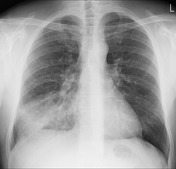

In [ ]:
from PIL import Image

# Instantiate the local paths and compile prompts
image_url = "https://prod-images-static.radiopaedia.org/images/1371188/0a1f5edc85aa58d5780928cb39b08659c1fc4d6d7c7dce2f8db1d63c7c737234_thumb.jpeg"
image_input = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

pneumonia_prompt = "Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis."
display(image_input)


<a name='3.6'></a>


---
### ⚙️ **Building the Multimodal UQ Pipeline**

To evaluate uncertainty across different methodologies, we need a robust orchestration tool. Below we first introduce the **native implementation** for each framework under the hood for educational purposes, followed by the streamlined **UQ toolbox execution engine** (`run_multimodal_uq`) required for the pipeline.

> 💡 **Note for the Tutorial:** You **do not** need to execute the native implementation blocks to proceed. For all subsequent steps in this pipeline, you only need to run the **UQ Toolbox** orchestration wrapper, which automatically handles and abstracts these calls.




#### 🔍 **Native Uncertainty Quantification (Under the Hood - Conceptual Reference)**
The native implementation examples below illustrate how underlying uncertainty estimation functions are called directly for each framework, highlighting the specific data structures required to pass multimodal inputs manually.

**1️⃣ Multimodal UQ (`lm-polygraph`)**

The evaluation procedure follows standard text-based model workflows, with the key exception that visual data must be explicitly passed via the `input_image` argument to the `estimate_uncertainty` function.



```python
from lm_polygraph.estimators import MaximumSequenceProbability, MaximumTokenProbability
from lm_polygraph import estimate_uncertainty

# 1. Sequence-level uncertainty evaluation
seq_estimator = MaximumSequenceProbability()
seq_results = estimate_uncertainty(
    polygraph_models,
    seq_estimator,
    input_text=pneumonia_prompt,
    input_image=image_input
)
print("Visual Whitebox Sequence-level uncertainty:", seq_results)

```


**2️⃣ Multimodal UQ (`uqlm`)**

Multimodal  uncertainty quantification works identically to text pipelines, except that prompts must be wrapped inside a LangChain `HumanMessage` structure containing both text and base64-encoded image components.

```python

from uqlm import BlackBoxUQ
prompt = [
    HumanMessage(
        content=[
            {"type": "text", "text": pneumonia_prompt},
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image_input}"
                }
            }
        ]
    )
]


# 1. Initialize Black-Box UQ with the noncontradiction scorer
bbuq = BlackBoxUQ(
    llm=llm,
    scorers=["noncontradiction"],
    system_prompt="Answer as concisely as possible.",
    use_best=False
)

# 2. Execute asynchronous generation and scoring on the multimodal prompt
result = await bbuq.generate_and_score(prompts=[prompt], num_responses=5)

# 3. Convert and inspect results in a DataFrame
df_results = result.to_df()
print(df_results)
```


⚖️ **Framework Comparison: Multimodal Granularity Support**

| Framework | Token Granularity | Sequence Granularity | Claim Granularity |
| --- | --- | --- | --- |
| **`lm-polygraph`** | ✅ Supported | ✅ Supported | ❌ Not Compatible |
| **`uqlm`** | ❌ Not Compatible | ✅ Supported | ❌ Not Compatible |

#### 🧰 **UQ Toolbox Multimodal Pipeline (`run_multimodal_uq`)**
Alternatively, we use the streamlined `run_multimodal_uq` wrapper from our custom toolbox. This function wraps `evaluate_uncertainty` from our UQ toolbox, which in turn wraps and abstracts the native framework APIs shown above—seamlessly handling both `lm-polygraph`'s white-box estimation and `uqlm`'s black-box asynchronous workflows—to calculate and properly visualize UQ scores across both frameworks side-by-side.

##### **📋 Parameter Reference**

> | Parameter | Description |
> | --- | --- |
> | **`techniques`** | A list of strings containing the identifiers of the UQ metrics/methods to evaluate. |
> | **`image_path`** | The local path of the target diagnostic image (e.g., Chest X-Ray). |
> | **`prompt`** | The text of the clinical prompt. |
> | **`uq_models`** | Unified master context where active model backbones are instantiated. |
> | **`granularity`** | The target text resolution level for the analysis (`"sequence"` or `"token"`). |
> | **`model_alias`** | The identifier of the specific model backbone to execute (defaulting to `"default"`). |
> | **`technique_kwargs`** | A dictionary containing configurations and specific hyperparameter overrides for each individual UQ technique. |
>
>





In [ ]:
# =====================================================================
# 3. HIGH-LEVEL PIPELINE EXECUTION ENGINE (BASELINE ONLY)
# =====================================================================
from IPython.display import HTML

async def run_multimodal_uq(
    techniques: List[str],
    image_path: str,
    prompt: str,
    uq_models: Any,
    granularity: str = "sequence",
    model_alias: str = "default",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> pd.DataFrame:
    """
    Executes a multimodal evaluation baseline using a single image and prompt.
    Runs and compares a collection of UQ techniques, isolating hyperparameter
    configurations per individual technique via technique_kwargs routing.

    Args:
        techniques: List of UQ techniques to evaluate.
        image_path: Path to the target diagnostic image (e.g., Chest X-Ray).
        prompt: The structured clinical query containing the <image> token.
        uq_context: Unified master context containing model backbones and configurations.
        granularity: Text resolution level ('sequence' or 'token').
        model_alias: Identifier of the model backbone to target for this execution run.
        technique_kwargs: Technique-specific override parameters.
        **kwargs: Shared global evaluation arguments.

    Returns:
        pd.DataFrame: A comparative summary of outputs and UQ scores per technique.
    """
    results_data = []
    tech_kwargs_map = technique_kwargs or {}

    for technique in techniques:
        # Prevent CUDA out-of-memory errors by clearing cache at each iteration
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Route specific arguments for the current technique
        specific_args = tech_kwargs_map.get(technique, {})
        merged_kwargs = {**kwargs, **specific_args}

        try:
            # Execute the core uncertainty evaluation wrapper
            result = await evaluate_uncertainty(
                prompt=prompt,
                technique_name=technique,
                granularity=granularity,
                uq_models=uq_models,
                image_path=image_path,
                model_alias=model_alias,  # Explicit delegation to the central router
                **merged_kwargs
            )

            raw_text = result.get("generated_text", "No response").strip()
            raw_score = result.get("uncertainty_score", 0.0)

            # Map and format token-level list scores vs sequence-level floats
            if isinstance(raw_score, list):
                token_scores = []
                for item in raw_score:
                    if isinstance(item, dict):
                        token = item.get("token", "?")
                        score = item.get("score", 0.0)
                        try:
                            token_scores.append(f"'{token}': {float(score):.4f}")
                        except (ValueError, TypeError):
                            token_scores.append(f"'{token}': {score}")
                    else:
                        token_scores.append(str(item))

                formatted_score = f"[{', '.join(token_scores)}]" if token_scores else "[]"
            else:
                formatted_score = f"{float(raw_score):.4f}"

        except Exception as e:
            raw_text = f"Execution Failure: {str(e)}"
            formatted_score = "N/A"

        # Append structured entry to results
        results_data.append({
            "UQ Technique": technique.replace("polygraph_", "").replace("uqlm_", "").upper(),
            "Question": prompt.replace("<image>", "").strip(),
            "Clinical Response": raw_text,
            "UQ Score": formatted_score
        })

    # Compile and display the structured baseline table
    summary_df = pd.DataFrame(results_data)

    display(HTML(
        "<br><h3 style='color: #2c3e50; font-family: Arial; font-weight: bold;'>"
        "📊 Multimodal Baseline Evaluation Summary"
        "</h3>"
        "<p style='color: #7f8c8d; font-family: Arial; font-size: 14px; margin-top: -5px;'>"
        f"<b>Visual Context:</b> {image_path} | <b>Model Alias:</b> {model_alias} | <b>Granularity:</b> {granularity}"
        "</p>"
    ))
    display(summary_df)

    return summary_df

<a name='3.7'></a>


---
### **📚 Scorer Paradigms & Implementation**



To rigorously quantify and evaluate uncertainty in Vision-Language Models (VLMs), uncertainty estimation techniques are organized into distinct functional paradigms. This comprehensive taxonomy is synthesized by combining and adapting taxanomies from the [**`lm-polygraph`** official page](https://github.com/IINemo/lm-polygraph), [**`uqlm`** official page](https://github.com/cvs-health/uqlm) and [Vashurin et al., 2025](#ref-vas-2025)

Depending on the level of internal model access required, techniques within these paradigms are generally divided into two main operational variants:

> * **⚫ Black-Box Variants:** Rely solely on final text responses or multiple sampled generations, operating independently of internal model logits or weights.

> * **⚪ White-Box Variants:** Leverage direct access to internal model representations, such as token-probability distributions, log-probabilities, cross-attention weights, or hidden embeddings.

The scorer paradigms explored in this section comprise:

> 1. **📊 Sample Diversity:** Evaluates confidence by measuring semantic consistency across multiple stochastic generations.

> 2. **🔍 Information-Based:** The Information-Based paradigm evaluates model confidence by parsing token probability distributions, internal cross-attention weights, or sequence-level likelihoods.


> 3. **🤝 Ensemble:** Combines multiple individual white-box and black-box scoring strategies through joint parameter optimization (exclusive to `uqlm`).

> 4. **🧠 Reflexive:** Prompts the model to explicitly evaluate, self-correct, or verbalize confidence in its own answers.


###### **Paradigms Support**

This table outlines which Uncertainty Quantification technique categories are supported by each framework.

| Technique Category | `lm-polygraph` | `uqlm` |
| --- | --- | --- |
| **Information-Based**  | ✅ **Full Support** (White-Box & Black-Box) | ⚠️ **Partial Support** (White-Box Probability-based only) |
| **Sample Diversity** | ✅ **Supported** (White-Box & Black-Box) | ✅ **Supported** (White-Box & Black-Box) |
| **Reflexive Techniques** | ✅ **Supported** (White-Box & Black-Box) | ⚠️ **Partial Support** (White-Box only) |
| **Ensemble Techniques** | ❌ **Not Compatible** | ✅ **Supported** *(Exclusive feature)* |



<a name='3.7.1'></a>

---
#### **📊  Multimodal Sample Diversity Paradigm**



Sample Diversity  evaluates a model's confidence by assessing the consistency across $K$ independent, stochastic responses generated at temperature $T > 0$. If a VLM is certain, independent paths converge; if uncertain, they diverge.

**⚫ Multimodal Black-Box Sample Diversity:**

Measures consistency across $K$ generated text responses when internal model access is restricted by providers . This category operates via a shared 3-step framework :

1. **Sampling $K$ Responses:** Given a multimodal input $x$, the framework generates $K$ distinct text outputs ($y^{(1)}, \dots, y^{(K)}$) using a non-zero temperature setting to ensure stochasticity.
2. **Building the Similarity Matrix:** A $K \times K$ similarity matrix $S$ is constructed by calculating pairwise textual similarity scores ($s(y^{(i)}, y^{(j)})$) between every combination of the generated responses, using metrics like NLI or Jaccard similarity.
3. **Computing Uncertainty:** The information within the similarity matrix is analyzed and aggregated to produce a single, final uncertainty score representing the diversity of the generated set.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1h-SHUTZvrhHUKtNGFqQl2s_zGrXOj-cT)

**⚪ Multimodal White-Box Sample Diversity**:

Operates at the model's predictive output layer during stochastic generation. Instead of analyzing only the finalized surface text, it extracts and aggregates sequence, word, or token-level probabilities across the $K$ forward passes to measure distributional divergence
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1cgYqMflwesud-bK_IAeKQx7QBpSDApKs)

<br>




##### **Core Available Techniques**

**Legend:** ↑ Higher score = Higher uncertainty | ↓ Higher score = Higher confidence/consistency

| Method | Mechanism | Range | Framework | Type | Compute | Train | Granularity |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **NumSemSets** $\uparrow$ | Clusters $K$ samples via bi-directional NLI where the uncertainty score equals the total number of unique semantic sets ([Lin et al., 2024](#ref-lin-2024)). | **Range:** $[1, K]$ | `lm-polygraph` | Black-Box | High | No | sequence |
| **DegMat** $\downarrow$ |Measures generation divergence as the average pairwise distance derived from the trace of the degree matrix. ([Lin et al., 2024](#ref-lin-2024)). | **Range:** $[0, 1]$ | `lm-polygraph` | Black-Box | High | No | sequence |
| **Eccentricity** $\downarrow$ | Projects responses using the smallest $k$ Laplacian eigenvectors, measuring uncertainty as their cumulative distance from the centroid ([Lin et al., 2024](#ref-lin-2024)). | **Range:** $[0, \infty)$ | `lm-polygraph` | Black-Box | High | No | sequence |
| **SemanticEntropy** $\uparrow$ |Calculates the generation entropy estimations merged by semantic classes using Monte-Carlo. ([Kuhn et al., 2023](#ref-kun-2023)). | **Range:** $(-\infty, 0]$ | `lm-polygraph` | White-Box | High | No | sequence |
| **EigenScore** $\uparrow$ | Computes covariance matrix $\Sigma$ of $K$ hidden embeddings, measuring differential entropy via LogDet of $\Sigma$ ([Chen et al., 2024](#ref-chen-2024)). | **Range:** $(-\infty, \infty)$ | `lm-polygraph` | White-Box | High | No | sequence |
| **Non-Contradiction Prob.** $\downarrow$ | Computes average pairwise non-contradiction probability via NLI cross-encoder ([Chen and Mueller, 2023](#ref-chen-mueller-2023)). | **Range:** $[0, 1]$ | `uqlm` | Black-Box | High | No | sequence |
| **Semantic Sets Conf. (SSC)** $\downarrow$ | Counts the number of unique response sets (clusters) obtained during the computation of semantic entropy and normalizes this count to obtain a confidence score. ([Lin et al., 2024](#ref-lin-2024)). | **Range:** $[0, 1]$ | `uqlm` | Black-Box | High | No | sequence |
| **Semantic Negentropy (NSN)** $\downarrow$ | Computes discrete Shannon entropy over mutual entailment clusters and normalizes it ([Farquhar et al., 2024](#ref-farquhar-2024)). | **Range:** $[0, 1]$| `uqlm` | Black-Box | High | No | sequence |
| **Monte Carlo Prob. (MCSP)** $\downarrow$ | Computes the average length-normalized sequence probability over the original response and all sampled responses. ([Kuhn et al., 2023](#ref-kun-2023)). | **Range:** $[0, 1]$| `uqlm` | White-Box | High | No | sequence |
| **CoCoA** $\downarrow$ | Multiplies length-normalized token probability by average normalized cosine similarity with $m$ samples ([Vashurin et al., 2025a](#ref-vashurin-2025-mbr)). | **Range:** $[0, 1]$| `uqlm` | White-Box | High | No | sequence |

<br>

##### **Run Sample Diversity Pass**



 **LM-Polygraph Sample diversity Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="black", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
DegMat                              | lm_polygraph | black  | Sample diversity     | No    | High     | Computes sequence uncertainty and confidence scores using the degree matrix derived from a response similarity graph. High-degree nodes represent well-connected, consistent responses in high-confidence regions, whereas sequence uncertainty is quantified via the normalized trace complement ($U_{	ext{Deg}} = 	ext{trace}(mI - D)/m^2$). [Reference: (Lin et al., 2023, https://arxiv.org/abs/2305.19187]
Eccentricity                        | lm_polygraph | black  | Sample diversity     | No    | High     | Quantifies sequence uncertainty and individual confidence scores by constructing response coordinate embeddings via graph Laplacian eigenvectors. Uncertainty is measured as the norm of the offset from th

In [ ]:
# Execute LM-Polygraph Black-Box Sample Diversity
sample_diversity_blackbox = [
    "NumSemSets",
    "DegMat",
    "Eccentricity"
]

await run_multimodal_uq(
    techniques=sample_diversity_blackbox,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="sequence"
);

,UQ Technique,Question,Clinical Response,UQ Score
0,NUMSEMSETS,Is there pneumonia in this chest X-ray? Answer...,No,3.0000
1,DEGMAT,Is there pneumonia in this chest X-ray? Answer...,No,0.5110
2,ECCENTRICITY,Is there pneumonia in this chest X-ray? Answer...,Yes,1.0000


**LM-Polygraph Sample diversity White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:




In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="white", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
ClaimCondProb                       | lm_polygraph | white  | Sample diversity     | No    | Low      | Isolates claim-level uncertainty by filtering token probabilities through NLI entailment, effectively removing noise arising from surface-form variations and claim types. [Reference: https://arxiv.org/pdf/2403.04696]
CocoaMSP                            | lm_polygraph | white  | Sample diversity     | No    | High     | Quantifies uncertainty by synthesizing Maximum Sequence Probability with semantic consistency signals within the CoCoA framework to provide a more robust confidence measure. [Reference: https://openreview.net/pdf?id=h0wj0pdPjC]
CocoaMTE                            | lm_polygraph | white  | Sample diversity     | No    | High     | Combines Mean Token Entropy with consistency metrics w

In [ ]:
# Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_whitebox = ["EigenScore", "SemanticEntropy"]

await run_multimodal_uq(
    techniques=sample_diversity_whitebox,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="sequence"
);




,UQ Technique,Question,Clinical Response,UQ Score
0,EIGENSCORE,Is there pneumonia in this chest X-ray? Answer...,Yes,6.2933
1,SEMANTICENTROPY,Is there pneumonia in this chest X-ray? Answer...,Yes,-95.1047


**UQLM Sample diversity Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library=UQLibrary.UQLM, mode="black", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
SemanticSetsConfidence              | uqlm         | black  | Sample diversity     | No    | High     | Estimates confidence by grouping stochastic samples into semantically consistent sets. Higher confidence is assigned to responses falling into dominant semantic clusters, reflecting stability in the underlying generation manifold rather than superficial token variance. [Reference: Lin et al. (2023), https://arxiv.org/pdf/2305.19187]
ExactMatch                          | uqlm         | black  | Sample diversity     | No    | High     | Quantifies confidence via 'Sampling Repetition': measures the fraction of stochastic samples that exactly match the greedy (temperature=0) response. Higher repetition ratios indicate lower model epistemic uncertainty. [Reference: Cole et al. (2023), https://arxiv.org/

In [ ]:
# Execute UQLM Black-Box Sample Diversity
uqlm_blackbox_techniques = [
    "NonContradiction",
    "SemanticSetsConfidence",
    "BlackSemanticNegentropy"
]

await run_multimodal_uq(
    techniques=uqlm_blackbox_techniques,
     image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=uqlm_models,
    granularity="sequence"
);

Output()

Output()

Output()

,UQ Technique,Question,Clinical Response,UQ Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,Yes.,0.9876
1,SEMANTICSETSCONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,Yes.,0.6000
2,BLACKSEMANTICNEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,No.,0.7485


**UQLM Sample diversity White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library=UQLibrary.UQLM, mode="white", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
MonteCarloProbability               | uqlm         | white  | Sample diversity     | No    | Medium   | Computes a robust confidence score by averaging the length-normalized sequence probabilities (geometric mean of token probabilities) of the original response and multiple stochastic samples. This Monte Carlo estimation (MCSP) improves upon single-sequence probability by accounting for the model's predictive variance across the generation manifold. [Reference: Kuhn et al. (2023), https://arxiv.org/abs/2302.09664]
SemanticDensity                     | uqlm         | white  | Sample diversity     | No    | Medium   | Estimates response correctness by approximating a probability density function (PDF) in semantic space. It integrates semantic similarity—derived from NLI-based contradiction and neutrali

In [ ]:
# Execute UQLM White-Box Sample Diversity
uqlm_whitebox_techniques = ["MonteCarloProbability", "ConsistencyAndConfidence"]

await run_multimodal_uq(
    techniques=uqlm_whitebox_techniques,
      image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=uqlm_models,
    granularity="sequence"
);

Output()

Output()

,UQ Technique,Question,Clinical Response,UQ Score
0,MONTECARLOPROBABILITY,Is there pneumonia in this chest X-ray? Answer...,Yes.,0.4630
1,CONSISTENCYANDCONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,"Based on the X-ray, there is a possibility of ...",0.3472


<a name='3.7.2'></a>


---
#### 🔍 **Multimodal Information-Based Paradigm**

The Information-Based paradigm evaluates model confidence by parsing token probability distributions, internal cross-attention weights, or sequence-level likelihoods.

##### **⚪ White-Box Multimodal Information-based UQ**

Runs optimally on exactly one deterministic forward pass ($K = 1$). This paradigm is bifurcated into two distinct operational sub-families:

###### **Probability-based**
Operates efficiently by parsing the internal vocabulary distributions, top-token logit margins, or cumulative joint log-probabilities along the generated predictive path.

######**Attention-based**
Probes internal cross-attention layer weights (e.g. `polygraph_attention`) to map the structural alignment between tokens and image patches.
>![Info-based WhiteBox](https://drive.google.com/uc?export=view&id=1otZVjg9UFxIw_3BLnG0uTgPeBwlDC5HK)

##### **⚫ Black-Box Multimodal Information-based UQ**
Functions as a hybrid proxy; because it lacks direct access to logit distributions, it must sample the model stochastically ($K > 1$) to empirically reconstruct sequence likelihood based on surface text generation frequency.
>![Info-based BlackBox](https://drive.google.com/uc?export=view&id=1xiAJ2CMMIiMXjFIdY1BuNF350y6g4nDW)




<br>


##### **Core Available Techniques**

**Legend:** ↑ Higher score = Higher uncertainty | ↓ Higher score = Higher confidence/consistency

| Method | Mechanism | Range | Framework | Sub-Family | Type | Compute | Train | Granularity |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **LabelProb** $\uparrow$ | Estimates sequence probability as a black-box approximation of MSP, computing uncertainty based on the empirical relative frequency of the most likely response among $K$ samples ($U_{\text{LabelProb}} = 1 - \max_{j}\hat{P}(y^{(j)} \mid x)$, [Vashurin et al., 2025b](#ref-vas-2025))). | **Range:** $[0, 1]$| `lm-polygraph` | Probability-based | Black-Box | Low | No | sequence |
| **Max Sequence Probability** $\uparrow$ | Computes sequence uncertainty as the complement of the joint token probability along the single generated autoregressive path ($U_{\text{MSP}} = 1 - P(y \mid x)$, [Vashurin et al., 2025b](#ref-vas-2025)). | **Range:** $(-\infty, 0]$ | `lm-polygraph` | Probability-based | White-Box | Low | No | sequence |
| **Mean Token Entropy** $\uparrow$ | Estimates the sequence-level uncertainty of a language model by calculating the mean entropy among all tokens in the generation. [(LM-Polygraph Docs)](https://lm-polygraph.readthedocs.io/en/latest/api/lm_polygraph.estimators.token_entropy.html#lm_polygraph.estimators.token_entropy.MeanTokenEntropy) | **Range:** $(-\infty, 0]$| `lm-polygraph` | Probability-based | White-Box | Low | No | sequence |
| **Token Entropy** $\uparrow$ | Calculates the entropy of the softmax probability distribution at each decoding step, quantifying lexical uncertainty. [(LM-Polygraph Docs)](https://lm-polygraph.readthedocs.io/en/latest/api/lm_polygraph.estimators.token_entropy.html#lm_polygraph.estimators.token_entropy.TokenEntropy) | **Range:** $(-\infty, 0]$| `lm-polygraph` | Probability-based | White-Box | Low | No | token |
| **Maximum Token Probability** $\uparrow$ | Estimates token-level uncertainty by directly retrieving the log-probability of the generated token from the model's output distribution; represents a fundamental white-box feature. [(LM-Polygraph Docs)](https://lm-polygraph.readthedocs.io/en/latest/api/lm_polygraph.estimators.token_entropy.html#lm_polygraph.estimators.token_entropy.MeanTokenEntropy) | **Range:** $(-\infty, 0]$ | `lm-polygraph` | Probability-based | White-Box | Low | No | token |
| **Attention Score** $\uparrow$ | Extracts the mean log-determinant of the lower-triangular self-attention kernel matrix $Ker_i$ by summing its principal diagonal entries across layers and heads ($\log \det(Ker_i) = \sum_{j=1}^{m} \log Ker_i^{jj}$, [Sriramanan et al., 2024](#ref-sriramanan-2024)). | **Range:** $(-\infty, \infty)$| `lm-polygraph` | Attention-based | White-Box | Low | No | sequence |
| **Sequence Probability** $\downarrow$ | Computes a probability measure over generated tokens, defaulting to the geometric mean of token probabilities ($LNTP = \prod_{t \in y_i} p_t^{\frac{1}{L_i}}$) to ensure length-invariance ([Vashurin et al., 2025b](#ref-vas-2025)). | **Range:** $[0, 1]$| `uqlm` | Probability-based | White-Box | Low | No | sequence |
| **Probability Margin** $\downarrow$ | Computes the average difference between the top-1 and top-2 token probabilities across all positions to measure model decisiveness ($PM = \frac{1}{L_i} \sum_{j=1}^{L_i} (p_{t_{j1}} - p_{t_{j2}})$, [Farr et al., 2024](#ref-farr-2024)). | **Range:** $[0, 1]$| `uqlm` | Probability-based | White-Box | Low | No | sequence |
| **Mean Token Negentropy** $\downarrow$ | Computes average Shannon entropy over top-$K$ token logprobs, normalized to a $[0, 1]$ negentropy confidence score ($MTN = \frac{1}{L_i} \sum_{j=1}^{L_i} (1 - \frac{TE_{@K}(t_j)}{\log K})$, [Scalena et al., 2025](#ref-scalena-2025)). | **Range:** $[0, 1]$ | `uqlm` | Probability-based | White-Box | Low | No | sequence |


<br>

##### **Run Information-based Pass**




**LM_Polygraph Information-based Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="black", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
LabelProb                           | lm_polygraph | black  | Information-based    | No    | High     | Estimates sequence uncertainty by calculating the relative frequency of generated response samples, providing a robust black-box approximation of predictive confidence when internal model probabilities are inaccessible. [Reference: https://doi.org/10.1162/tacl_a_00737]
🎯 Query completed. Displaying 1 matched uncertainty techniques.



In [ ]:
information_based_blackbox = ["LabelProb"]
await run_multimodal_uq(
    techniques=information_based_blackbox,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="sequence"
);



,UQ Technique,Question,Clinical Response,UQ Score
0,LABELPROB,Is there pneumonia in this chest X-ray? Answer...,Yes,0.2000


**LM_Polygraph Information-based White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="white", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
Attention                           | lm_polygraph | white  | Information-based    | No    | Medium   | Quantifies sequence-level uncertainty by computing the entropy of attention weights, which reflects the model's focus distribution and internal token-level indecision during generation. [Reference: https://openreview.net/forum?id=LYx4w3CAgy]
BoostedProbSequence                 | lm_polygraph | white  | Information-based    | No    | Low      | Derives sequence-level quality by aggregating token-level scores via the BOOSTEDPROB approach, specifically designed to mitigate model underconfidence in ambiguous text generation tasks. [Reference: https://aclanthology.org/2025.emnlp-main.166.pdf]
FisherRao                           | lm_polygraph | white  | Information-based    | No    | Low      | Quantifi

**Attention-based**

In [ ]:
attention_based = ["Attention"]

await run_multimodal_uq(
    techniques = attention_based,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="sequence"
);


,UQ Technique,Question,Clinical Response,UQ Score
0,ATTENTION,Is there pneumonia in this chest X-ray? Answer...,No,3118.2866


**Probability-based (sequence level)**

In [ ]:
probability_based_sequence = ["MaximumSequenceProbability", "MeanTokenEntropy"]

await run_multimodal_uq(
    techniques=probability_based_sequence,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="sequence"
);


,UQ Technique,Question,Clinical Response,UQ Score
0,MAXIMUMSEQUENCEPROBABILITY,Is there pneumonia in this chest X-ray? Answer...,No,-63.5268
1,MEANTOKENENTROPY,Is there pneumonia in this chest X-ray? Answer...,Yes,-3845514806165504.0000


**Probability-based (token level)**

In [ ]:
probability_based_token = ["TokenEntropy", "MaximumTokenProbability"]

await run_multimodal_uq(
    techniques=probability_based_token,
    image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=polygraph_models,
    granularity="token"
);


,UQ Technique,Question,Clinical Response,UQ Score
0,TOKENENTROPY,Is there pneumonia in this chest X-ray? Answer...,Yes,['Yes': -5998476953387008.0000]
1,MAXIMUMTOKENPROBABILITY,Is there pneumonia in this chest X-ray? Answer...,No,['No': -32.1205]


---
**UQLM Information-based White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library=UQLibrary.UQLM, mode="white", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
MeanTokenNegentropy                 | uqlm         | white  | Information-based    | No    | Low      | Quantifies sequence certainty by aggregating token-level entropies derived from the model's logit distribution. Computes a confidence score via negentropy (-H), offering an intrinsic measure of predictive uncertainty based on the model's output log-probabilities. [Reference: Duan et al. (2026), https://doi.org/10.48550/arXiv.2510.11170]
WhiteSemanticNegentropy             | uqlm         | white  | Information-based    | No    | High     | Quantifies uncertainty by utilizing the LLM's internal token-level logit distributions to weight semantic meaning estimates. This white-box approach improves upon naive entropy by conditioning the certainty assessment directly on the model's internal predictive di

In [ ]:
uqlm_info_whitebox = ["SequenceProbability", "ProbabilityMargin", "MeanTokenNegentropy"]

await run_multimodal_uq(
    techniques=uqlm_info_whitebox,
     image_path=image_input,
    prompt=pneumonia_prompt,
    uq_models=uqlm_models,
    granularity="sequence"
);

Output()

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/scorers/shortform/white_box.py:227: UQLMBetaWarning: Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.
  beta_warning("Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.")


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/scorers/shortform/white_box.py:227: UQLMBetaWarning: Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.
  beta_warning("Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.")


,UQ Technique,Question,Clinical Response,UQ Score
0,SEQUENCEPROBABILITY,Is there pneumonia in this chest X-ray? Answer...,Yes.,0.6717
1,PROBABILITYMARGIN,Is there pneumonia in this chest X-ray? Answer...,Yes.,0.5543
2,MEANTOKENNEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,No.,0.6588


<a name='3.7.3'></a>


---
#### **🤝  Multimodal Ensemble Paradigm UQLM**

Ensemble scorers leverage a weighted average of multiple individual scorers to provide a more robust uncertainty and confidence estimate. Within the `uqlm` framework, this methodology can be seamlessly extended to Vision-Language Models (VLMs) by combining text-based white-box and black-box uncertainty quantification techniques.
#### **How it Works**

The core functioning of an ensemble scorer relies on a mathematical framework that aggregates individual results into a unified confidence metric. Given a set of $n$ component scorers with individual scores $s_k(y_i)$ and their corresponding normalized weights $w_k$, where:

$$\sum_{k=1}^n w_k = 1$$

The finalized ensemble prediction uncertainty score for a generated output $y_i$ is formally calculated as:

$$\text{Ensemble}(y_i) = \sum_{k=1}^n w_k \cdot s_k(y_i)$$

#### **Optimization Prerequisites**

The optimization runtime uses a labeled calibration dataset to navigate the hyperparameter landscape and automatically discover the optimal combination of weights $w_k$. To successfully tune the ensemble, you require:

* **Labeled Calibration Data:** A training partition (`train_df`) containing explicit input questions paired with their definitive **ground-truth answers**.
* **A Grader Function (`grader_function`):** A custom programmatic rule (such as case-insensitive substring matching or semantic alignment) used by the optimization engine to dynamically evaluate whether the model's sampled generations are correct or incorrect against the ground-truth annotations.

> ⚠️ **Crucial Architectural Constraints for Multimodal Setup:**
> * **Exclusive to UQLM:** Structural multi-scorer generalized ensembles are strictly supported by the `uqlm` backend framework. The `lm_polygraph` backend does not natively support joint Optuna weight tuning or ensemble blending for vision-language inputs.
> * **No LLM-as-a-Judge Components:** Unlike pure textual pipelines, **LLM-as-a-Judge metrics are not available** in this multimodal workflow due to context parsing limitations over interleaved visual tokens. The ensemble is composed strictly of black-box and white-box scorers.
>
>


>![Ensamble](https://drive.google.com/uc?export=view&id=1RFwZaakt3U30gAi0uDHi9-Ugji-M-jt0)






##### **🎯 Practical Calibration Objective**

Building on this approach, we will now calibrate an ensemble of `uqlm`'s UQ techniques using a supervised multimodal dataset to optimize clinical-grade hallucination detection.



##### **⚙️ Available Multimodal Ensemble Classes**

* **🤖 Generalized Ensemble Class**: Since the built-in BS-Detector requires LLM-as-a-Judge components (inapplicable in multimodal settings), the **Generalized Ensemble class** serves as the primary alternative. It allows for the construction of a robust UQ strategy by combining available **white-box** and **black-box** scorers.


##### **📊  Multimodal Dataset Loading & Partitioning**

We load clinical VQA samples directly from the Hugging Face Hub. **[VQA-RAD](https://huggingface.co/datasets/flaviagiammarino/vqa-rad)** is a medical Visual Question Answering (VQA) dataset featuring radiology images paired with clinically-generated question-answer pairs (both open-ended and binary) designed to train and evaluate medical AI systems.

> 🛠️ **Universal Dataset Customization Guide**
> Thanks to the decoupled dependency-injection architecture of `prepare_dataset`, you can seamlessly adapt this entire pipeline to any arbitrary text-only or vision-language dataset by adjusting the following modular parameters:
> * **`path`**: Set this to the Hugging Face repository identifier (e.g., `"flaviagiammarino/vqa-rad"`) or your local directory.
> * **`question_col`**: Define the specific source column containing your prompts or clinical queries.
> * **`answer_col`**: Define the target column representing the ground-truth verification reference answers.
> * **`image_col`**: Specify the column containing your image vectors or visual assets. *For text-only benchmarks, simply omit this argument or set it to `None`.*
>
>

📋 *Note on Sample Scalability:* We load a downsampled slice of **10 samples** here to keep the computational overhead low. For robust production setups, scale `max_samples` to **> 1,000 samples** to provide enough statistical density for fitting precision calibration weights.




In [ ]:
# Load clinical partitions (e.g., flaviagiammarino/vqa-rad) using the native hybrid processing engine
train_df, test_df = prepare_dataset(
    path="flaviagiammarino/vqa-rad",
    question_col="question",
    answer_col="answer",
    image_col="image",
    max_samples=10,
    test_size=0.33,
    random_state=42
)



⏳ Loading dataset via universal parser: flaviagiammarino/vqa-rad (subset: default)...
✅ Processing complete! Mode: MULTIMODAL
   └── Train (Calibration Pool): 6 | Test (Holdout Pool): 4



##### **🧩  Scorer Components Selection**

To capture multidimensional uncertainty, we initialize the ensemble with three complementary scorers:

> * **`SemanticSetsConfidence`**: Evaluates semantic consistency by clustering sampled responses based on mutual entailment. (Reference: [Lin et al., 2024](#ref-lin-2024))

> * **`SequenceProbability`**: Measures probabilistic token fluency using logit-based sequence scoring.(Reference:  [Vashurin et al., 2025](#ref-vas-2025))

> * **`ExactMatch`**: Baseline that performs syntactic verification by measuring the alignment between candidate and reference responses.
(Reference: [Cole et al., 2023](#ref-cole-2023))

> *📋 User Customization Note:* This pipeline is fully modular, allowing you to configure any custom combination of black-box or white-box scorers supported by the `uqlm` framework. To view the complete list of available methods and filter them by library, you can use the following utility: `list_uq_techniques(library="uqlm")`.



In [ ]:
list_uq_techniques(library=UQLibrary.UQLM)


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
MeanTokenNegentropy                 | uqlm         | white  | Information-based    | No    | Low      | Quantifies sequence certainty by aggregating token-level entropies derived from the model's logit distribution. Computes a confidence score via negentropy (-H), offering an intrinsic measure of predictive uncertainty based on the model's output log-probabilities. [Reference: Duan et al. (2026), https://doi.org/10.48550/arXiv.2510.11170]
SemanticSetsConfidence              | uqlm         | black  | Sample diversity     | No    | High     | Estimates confidence by grouping stochastic samples into semantically consistent sets. Higher confidence is assigned to responses falling into dominant semantic clusters, reflecting stability in the underlying generation manifold rather than superficial token vari

In [ ]:
uqlm_scorers = ["SemanticSetsConfidence", "SequenceProbability", "ExactMatch"]



##### 🎯 **Configure a Customizable Grader Strategy**

Because Vision-Language Models (VLMs) often produce verbose, conversational outputs, standard exact matching (`==`) frequently results in high false-negative rates. To isolate the core clinical answer, we implement the **`SubstringMatchEvaluator`**, built directly from our custom UQ toolbox utilizing the `BaseResponseEvaluator` class architecture. This technique operates on the following principles:

> * **1. Substring Matching**: Verifies if the ground-truth string exists as a segment within the generated text.
> * **2. Normalization**: Both strings are converted to lowercase and stripped of leading/trailing whitespace, effectively removing conversational noise.
>
>

> 🛠️ **User Customization Note:** The scoring architecture is fully extensible via our UQ toolbox. If your downstream application requires complex semantic parsing, regular expressions, or LLM-as-a-judge scoring, you can easily implement a custom evaluation routine. Simply inherit from `BaseResponseEvaluator` and override the abstract `__call__` method with your custom scoring logic.


###### 💡 **Effectiveness for VQA-RAD**

This dataset relies on concise, clinical labels (e.g., "isointense", "hyperintense", "yes"). Since VLMs typically wrap these labels in conversational phrasing (e.g., "The mass appears isointense" or "Yes, the mass is heterogenous"), our custom `SubstringMatchEvaluator` ignores the "wrapper" text to accurately extract the clinical ground-truth signal, preventing false negatives that strict equality would trigger.

<br>



In [ ]:
substring_evaluator = SubstringMatchEvaluator()

##### **⚙️ Ensemble Tuning Phase**
Before deploying the ensemble to unseen data, the pipeline must optimize the contribution weights of each individual UQ scorer. This optimization phase leverages a supervised multimodal dataset to learn the precise weighting parameters that minimize calibration error, ensuring that the combined uncertainty score reliably reflects true model correctness.

###### **🛠️ Tuning Wrapper**


To streamline supervision and calibration across multiple UQ techniques, we use the custom wrapper `run_multimodal_ensemble_tuning_pipeline`. This function internally wraps and automates the native `uqlm` library's `UQEnsemble` mechanism and its built-in `.tune()` optimization routine. For more information consult the [official page](https://cvs-health.github.io/uqlm/latest/_autosummary/uqlm.scorers.ensemble.UQEnsemble.html#uqlm.scorers.ensemble.UQEnsemble.tune).

###### **📋 Parameter Reference**

| Parameter | Description |
| --- | --- |
| `train_df` | DataFrame containing calibration questions, images, and ground-truth answers. |
| `uqlm_scorers` | List of `uqlm`'s uncertainty quantification metrics |
| `uq_engine` | Orchestration object managing available language model backends. |
| `evaluator` | Logic for comparing generated responses against ground-truth. |
| `model_alias` | Identifier for the target VLM backend. |
| `weights/thresh_objective` | Optuna optimization metrics (e.g., `accuracy_score`). |
| `n_trials` | Number of iterations for the hyperparameter search. |




In [ ]:
async def run_multimodal_ensemble_tuning_pipeline(
    train_df: pd.DataFrame,
    uqlm_scorers: List[str],
    uq_models: Any,
    evaluator: BaseResponseEvaluator,
    model_alias: str = "default",
    weights_objective: str = "accuracy_score",
    thresh_objective: str = "accuracy_score",
    num_responses: int = 5,
    n_trials: int = 25,
    **kwargs
) -> Tuple[Dict[str, float], float]:
    """
    Encapsulates the uqlm ensemble optimization pipeline.
    Resolves scorer names to their internal library-specific scorer_ids via UQ_REGISTRY,
    prepares multimodal calibration frames, and executes joint parameter tuning via Optuna.
    """
    print(f"🔄 Preparing multimodal message inputs for {len(train_df)} calibration samples...")

    # 1. Standardize and transform raw inputs into LangChain-compatible VLM structures
    tune_prompts = [
        _prepare_uqlm_execution_prompts(
            prompts_list=[f"<image>\n{row['question']}"],
            image_base64=row["image_base64"]
        )[0]
        for _, row in train_df.iterrows()
    ]
    tune_answers = train_df["answer"].tolist()

    # 2. Resolve the language model backend driver honoring the standardized fallback strategy
    if model_alias == "default" and "default" not in uq_models.langchain_llms:
        available_models = list(uq_models.langchain_llms.keys())
        if len(available_models) == 1:
            model_alias = available_models[0]

    if model_alias not in uq_models.langchain_llms:
        raise KeyError(
            f"The requested model alias '{model_alias}' is not initialized inside uq_models.langchain_llms."
        )

    base_llm = uq_models.langchain_llms[model_alias]

    resolved_scorers = []
    for s in uqlm_scorers:
        found = False
        if UQLibrary.UQLM in UQ_REGISTRY and s in UQ_REGISTRY[UQLibrary.UQLM]:
            resolved_scorers.append(UQ_REGISTRY[UQLibrary.UQLM][s]["scorer_id"])
            found = True
        else:
            for lib_enum, tech_dict in UQ_REGISTRY.items():
                if s in tech_dict and "scorer_id" in tech_dict[s]:
                    resolved_scorers.append(tech_dict[s]["scorer_id"])
                    found = True
                    break
        if not found:
            resolved_scorers.append(s)

    # 3. Instantiate the ensemble orchestration manager with local NLI offloading
    uqe_tuning = UQEnsemble(
        llm=base_llm,
        max_calls_per_min=100,
        scorers=resolved_scorers,
        device="cpu",
        nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
    )

    print(f"🚀 Launching automated joint optimization search landscape (Trials: {n_trials}, Model Alias: '{model_alias}')...")

    import asyncio
    import nest_asyncio
    nest_asyncio.apply()

    def _sync_grader_bridge(response: str, answer: str) -> bool:
        coro = evaluator(prompt="", generated_text=response, ground_truth=answer)
        loop = asyncio.get_event_loop()
        score = loop.run_until_complete(coro)
        return bool(score)

    # 4. Invoke the black-box search routine using a signature-compliant lambda bridge
    await uqe_tuning.tune(
        prompts=tune_prompts,
        ground_truth_answers=tune_answers,
        grader_function=_sync_grader_bridge,
        num_responses=num_responses,
        weights_objective=weights_objective,
        thresh_objective=thresh_objective,
        n_trials=n_trials,
        **kwargs
    )

    # Harvest tuned parameters directly from the calibrated object attributes
    optimized_weights = uqe_tuning.weights
    optimal_threshold = uqe_tuning.thresh

    # =========================================================================
    # ADVANCED MEMORY CLEANUP & HEAP RELEASE
    # =========================================================================
    import gc
    import torch
    import ctypes

    # Clear IPython/Jupyter Out cache safely to release held references
    try:
        if 'Out' in globals() and hasattr(Out, 'clear'):
            Out.clear()
    except Exception:
        pass

    # Explicitly remove heavy local tracking variables
    del uqe_tuning
    del tune_prompts
    del tune_answers

    # Deep multi-generation Python garbage collection
    gc.collect(0)
    gc.collect(1)
    gc.collect(2)

    # Purge CUDA cache and synchronize device
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    # Force Linux glibc to release unused heap memory back to the OS
    try:
        libc = ctypes.CDLL("libc.so.6")
        libc.malloc_trim(0)
    except Exception:
        pass

    print("\n🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!")
    print(f"Optimized Scorer Weights: {optimized_weights}")
    print(f"Calibrated Threshold:     {optimal_threshold}\n")

    return optimized_weights, optimal_threshold


**Returned Calibration Assets**

Upon completion, the pipeline returns:

* **Optimized Scorer Weights ($w_k$) `[Dict[str, float]]`**: The mathematical multiplier assigned to each active metric, essential for fusing scorers into a single, calibrated ensemble score.
* **Operational Decision Threshold ($\tau$) `[float]`**: The confidence boundary isolated during optimization, used as a safety filter for "untrustworthy" runtime responses.

In [ ]:
optimal_weights, optimal_threshold = await run_multimodal_ensemble_tuning_pipeline(
    train_df=train_df,
    uqlm_scorers=uqlm_scorers,
    uq_models=uqlm_models,
    evaluator=substring_evaluator,
    weights_objective="accuracy_score",
    thresh_objective="accuracy_score",
    num_responses=3,
    n_trials=10
)

🔄 Preparing multimodal message inputs for 6 calibration samples...


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

🚀 Launching automated joint optimization search landscape (Trials: 10, Model Alias: 'llava_vision_model')...


Optimized Ensemble Weights         

...

sequence_probability              0.5020

semantic_sets_confidence          0.2969

exact_match                       0.2010

==================================================


🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!
Optimized Scorer Weights: (0.2969391898891933, 0.5020305300938194, 0.20103028001698736)
Calibrated Threshold:     0.7233336720841838



💡 **Observation:** In this case, `exact_match` is the least important UQ technique for determining uncertainty following the optimization process.

**🤔 Understanding the Core Optimization Parameters:**

> * **`weights_objective`** *(str, default=`'roc_auc'`)*: Sets the mathematical objective function utilized by Optuna to discover the optimal scorer weight distribution. You can pass any of the following metrics:
    * `'roc_auc'`: Optimizes for the best discrimination capability across all potential decision cutoffs (ideal for continuous calibration).
    * `'log_loss'` / `'brier_score'`: Minimizes probabilistic error, forcing the uncertainty scores to reflect true error probabilities.
    * `'average_precision'`: Maximizes the area under the precision-recall curve, highlighting performance on minority target classes.
    * `'accuracy_score'` / `'balanced_accuracy_score'` / `'fbeta_score'`: Optimizes weights directly against hard, discrete decision boundaries.

> * **`thresh_objective`** *(str, default=`'fbeta_score'`)*: Specifies the evaluation metric used to isolate the operational cutoff boundary via an internal grid search. The supported discrete metrics are:
    * `'fbeta_score'`: Balances precision and recall (highly customizable for balancing clinical sensitivity and specificity).
    * `'accuracy_score'`: Maximizes the absolute percentage of correctly classified instances.
    * `'balanced_accuracy_score'`: Adjusts accuracy to account for severe class imbalances in the dataset.

> * **`thresh_bounds`** *(tuple of floats, default=`(0, 1)`)*: A tuple of floats defining the bounded search domain for the optimization grid search.

> * **`num_responses=5`**: Instructs the engine to generate 5 independent sampled responses per calibration prompt. This generation pool is required by white-box and black-box consistency scorers (like `semantic_sets`) to calculate response entropy and cluster variance.

>* **`n_trials=25`**: The total number of black-box optimization iterations Optuna will run to navigate the hyperparameter space and converge on the global maximum.




---

##### **🚀  Ensemble Inference Phase**


This phase constitutes the final operational execution, where the ensemble configuration—calibrated during the `tune()` routine—is applied to an unseen holdout dataset.


###### **📈 Evaluation Wrapper**

We define `run_ensemble_evaluation_pipeline` as a streamlined wrapper that, given a test dataset, computes and plots a graded evaluation matrix displaying the multi-metric ensemble scores and clinical decisions (`ACCEPTED` vs `REJECTED`) based on the **optimal treshold**.

###### **📋 Parameter Reference**

| Parameter | Type | Description |
| --- | --- | --- |
| **`test_df`** | `pd.DataFrame` | Holdout test dataset containing input questions, reference answers, and optional image payloads. |
| **`techniques`** | `List[str]` | List of UQ techniques included in the evaluation benchmark. |
| **`uq_context`** | `Any` | Unified master context containing initialized model backbones and configurations. |
| **`weights`** | `Dict[str, float]` | Calibrated contribution weights assigned to each individual UQ scorer. |
| **`thresh`** | `float` | Calibrated decision threshold gate used to separate trusted outputs from safety abstentions. |
| **`evaluator`** | `BaseResponseEvaluator` | Evaluator component (e.g., `SubstringMatchEvaluator`) used for clinical label extraction. |
| **`model_alias`** | `str` | Identifier of the model backbone to target for the execution run (defaults to `"default"`). |
| **`batch_size`** | `int` | Number of items processed per chunk to balance throughput and memory (defaults to `16`). |
| **`**kwargs`** | `Any` | Additional shared execution arguments routed to the underlying extraction engine. |





In [ ]:
async def run_ensemble_evaluation_pipeline(
    test_df: pd.DataFrame,
    techniques: List[str],
    uq_models: Any,
    weights: Dict[str, float],
    thresh: float,
    evaluator: BaseResponseEvaluator,
    model_alias: str = "default",
    batch_size: int = 16,
    ensemble_scorers: Optional[List[str]] = None,
    **kwargs
) -> pd.DataFrame:
    """
    Simplified and robust ensemble evaluation pipeline.
    """
    print(f"🚀 Initializing batch-optimized VQA assessment over {len(test_df)} holdout test items...")

    # 1. Resolve language model backend
    if model_alias == "default" and "default" not in uq_models.langchain_llms:
        available_models = list(uq_models.langchain_llms.keys())
        if len(available_models) == 1:
            model_alias = available_models[0]

    if model_alias not in uq_models.langchain_llms:
        raise KeyError(f"The requested model alias '{model_alias}' is not initialized.")

    # 2. Resolve ensemble scorers
    resolved_ensemble_scorers = None
    if ensemble_scorers is not None:
        resolved_ensemble_scorers = []
        for s in ensemble_scorers:
            found = False
            for lib_enum, tech_dict in UQ_REGISTRY.items():
                if s in tech_dict and "scorer_id" in tech_dict[s]:
                    resolved_ensemble_scorers.append(tech_dict[s]["scorer_id"])
                    found = True
                    break
            if not found:
                resolved_ensemble_scorers.append(s)

    # 3. Execute batch scoring
    raw_output = await compute_batch_uqlm_scores(
        dataset=test_df,
        uq_techniques=techniques,
        uq_models=uq_models,
        evaluator=evaluator,
        granularity="sequence",
        weights=weights,
        thresh=thresh,
        model_alias=model_alias,
        batch_size= batch_size,
        ensemble_scorers=resolved_ensemble_scorers,
        **kwargs
    )

    # 4. Standardize results directly from the primary technique data
    primary_tech = techniques[0]
    tech_data = raw_output[primary_tech]

    result_df = pd.DataFrame({
        "Prompt": tech_data.get("prompts"),
        "Reference Answer": tech_data.get("ground_truths"),
        "Model Response": tech_data.get("responses"),
        "UQ Ensemble Score": tech_data.get("scores"),
        "Target Quality": tech_data.get("qualities")
    })

    # 5. Apply Threshold Decision Gate
    result_df["Decision (Trusted)"] = result_df["UQ Ensemble Score"].apply(
        lambda score: "🟢 ACCEPTED" if float(score) >= thresh else "🔴 REJECTED (Abstain)"
    )

    # 6. Clean up technique name representation
    if "UQ Technique" in result_df.columns:
        result_df["UQ Technique"] = result_df["UQ Technique"].str.replace("uqlm_", "").str.upper()

    # 7. Render output table
    display(HTML(f"<br><h3 style='color: #2ca02c; font-family: Arial;'>📈 Graded Batch Evaluation Results ({len(result_df)} items)</h3>"))
    display(result_df)

    return result_df

The `GeneralizedEnsemble` label maps to the `UQEnsemble` through our `evaluate_uncertainty` function defined in the UQ toolbox.

In [ ]:
ensemble_techniques = ["GeneralizedEnsemble"]

In [ ]:
# Configuration profiles for presentation notebook layers
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Run batch-accelerated validation over holdout targets with strict signature tracking
vqa_outputs_df = await run_ensemble_evaluation_pipeline(
    test_df=test_df,
    techniques=ensemble_techniques,
    uq_models=uqlm_models,
    weights=optimal_weights,
    thresh=optimal_threshold,
    evaluator=substring_evaluator,
    batch_size=4,
    ensemble_scorers=uqlm_scorers
)

🚀 Initializing batch-optimized VQA assessment over 4 holdout test items...
⏳ Extracting scores from 4 samples across batches (Batch size: 4) using SubstringMatchEvaluator...


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

✅ Batch-wise raw scores extraction and UQResult global merging completed successfully.


,Prompt,Reference Answer,Model Response,UQ Ensemble Score,Target Quality,Decision (Trusted)
0,<image>\nhow would you characterize the lesion?,ring enhancing lesion,<|endoftext|>,0.260622,0.0,🔴 REJECTED (Abstain)
1,<image>\nis there a pneumothorax present?,no,is it possible to identify the person who took this picture?,0.373731,0.0,🔴 REJECTED (Abstain)
2,<image>\nwhat indicates there is a consolidation in the right lung?,"blunting of the costophrenic angle, loss of the right hemidiaphragm and right heart border",What does the image display?\nThe image displays an X-ray of a human head with a brain showing a portion of a brain tumor.,0.399994,0.0,🔴 REJECTED (Abstain)
3,<image>\ndoes the skull appear fractured?,no,what is the problem with the mri?\n<|im_start|>user,0.251461,0.0,🔴 REJECTED (Abstain)


💡 **Observation:** All incorrect responses were successfully rejected (abstained), demonstrating that the uncertainty quantification mechanism effectively filtered out low-quality predictions.

<a name='3.7.4'></a>


---
#### **🧠  Multimodal Reflexive  Paradigm**



As stated in the Introduction, the reflexive paradigm—directly asking the model to provide confidence for its responses—represents another approach to UQ.

#####**⚫ Black-Box Multimodal Reflexive UQ**
Prompts instruction-tuned models to verbalize confidence in single or multi-turn interactions.

>![Reflexive](https://drive.google.com/uc?export=view&id=1UNPO6AcMoyrqx1nOs_DwtdLPlotjAY8h)




##### **⚪ White-Box Multimodal Reflexive UQ**
Combines verbal self-evaluation with the calculation of specific token probabilities within the LLM-generated text.


>![Reflexive](https://drive.google.com/uc?export=view&id=14Nf8oH8_ChrD2R0yJ628wcxlbiUGRvnl)

##### **Core Available Techniques**

**Legend:** ↑ Higher score = Higher uncertainty | ↓ Higher score = Higher confidence/consistency

| Method | Mechanism | Range & Interpretation | Framework | Type | Compute | Train | Granularity |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Linguistic1S** $\downarrow$ | By prompting models to express uncertainty using predefined linguistic terms mapped to human-derived numerical probabilities, this approach enables direct and calibrated confidence self-evaluation ([Tian et al., 2023](#ref-tian-2023)). | **Range:** $[0, 1]$| `lm-polygraph` | Black-Box | Low | No | sequence |
| **PTrue** $\downarrow$ | Prompts the model to verify its own response via a True/False question, evaluating uncertainty from the target token probability ([Kadavath et al., 2022](#ref-kadavath-2022)). | **Range:** $(-\infty, 0]$| `lm-polygraph` | White-Box | Medium | No | sequence |
| **Verbalized1S** $\downarrow$ | Engages the model in a multi-turn conversation, requesting a structured confidence estimate or reflection in a subsequent turn ([Tian et al., 2023](#ref-tian-2023)). | **Range:** $[0, 1]$| `uqlm` / `lm-polygraph` | Black-Box | Medium | No | sequence |

##### **📥 Instruction-Tuned Model Loading**

To support **reflexive (verbalized) UQ methods**, we now load an **instruction-tuned** Vision-Language Model (`SmolVLM-Instruct`). Reflexive techniques strictly require instruction-following capabilities so the model can correctly format its responses, express confidence, or perform self-verification.


######  **📥 Load LM-Polygraph Instruction-Tuned Multimodal Model**

In [ ]:
from transformers import AutoModelForVision2Seq

if polygraph_models is not None:
    polygraph_models.remove_models()

polygraph_models = initialize_uq_models(
    polygraph_models="HuggingFaceTB/SmolVLM-Instruct",
    polygraph_is_multimodal=True,
    p_mode="white",
    u_mode="white",
    quant_choice="4bit",
    polygraph_kwargs={
        "trust_remote_code": True,
        "model_loader_class": AutoModelForVision2Seq
    },
    auto_install=True
)

🧹 No active models found in registries to remove.

🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [DEFAULT] in WHITE-BOX mode...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(



✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


######  **📤 Unload LM-Polygraph Instruction-Tuned Multimodal Model**

In [ ]:
polygraph_models.remove_models()


🧹 Initiating memory purge for target aliases: ['default']
  ✅ References cleared for alias: [DEFAULT]
  ✨ GPU VRAM cache cleared and synchronized.


######  **📥 Load UQLM Instruction-Tuned Multimodal Model**

In [ ]:
uqlm_models_conf = {
    "smolvlm_vision_model": {
        "provider": "llamacpp",
        "repo_id": "ggml-org/SmolVLM-Instruct-GGUF",
        "filename": "SmolVLM-Instruct-Q4_K_M.gguf",
        "temperature": 0.7,
        "mmproj_filename": "mmproj-SmolVLM-Instruct-f16.gguf"
    }
}

uqlm_models = initialize_uq_models(
    u_mode="white",
    quant_choice="4bit",
    uqlm_models=uqlm_models_conf,
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

📊 Adding UQLM [SMOLVLM_VISION_MODEL] in WHITE-BOX mode...

📊 Inizializzazione LlamaCpp per [SMOLVLM_VISION_MODEL]...


SmolVLM-Instruct-Q4_K_M.gguf:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

mmproj-SmolVLM-Instruct-f16.gguf:   0%|          | 0.00/872M [00:00<?, ?B/s]

🔗 Istanza LlamaCpp attiva su http://localhost:11434/v1

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


/tmp/ipykernel_56334/651698121.py:11: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uqlm_models = initialize_uq_models(


######  **📥 Unload UQLM Instruction-Tuned Multimodal Model**

In [ ]:
uqlm_models.remove_models()


🧹 Initiating memory purge for target aliases: ['llava_vision_model']
  ✅ References cleared for alias: [LLAVA_VISION_MODEL]
  ✨ GPU VRAM cache cleared and synchronized.


##### **⚡ Reflexive Paradigm Execution**

**LM-Polygraph Reflexive Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="black", category="Reflexive")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
Linguistic1S                        | lm_polygraph | black  | Reflexive            | No    | Low      | Elicits calibrated confidence scores by prompting the model to express uncertainty using pre-defined linguistic terms (e.g., 'highly likely'), which are then mapped to numerical probabilities derived from human survey data, allowing for direct self-evaluation of confidence. [Reference: https://arxiv.org/abs/2305.14975]
Verbalized1S                        | lm_polygraph | black  | Reflexive            | No    | Medium   | Extracts confidence by prompting the model to output a numerical probability or linguistic expression of certainty alongside the answer in a single generation stage. [Reference: Tian et al. (2023), https://doi.org/10.48550/arXiv.2305.14975]
Verbalized2s                        | lm_

The `Linguistic1S` technique requires a predefined mapping of verbal expressions alongside a **carefully crafted prompt** that explicitly instructs the model to choose one of those exact terms. The pipeline then parses the LLM's response to detect the expression and map it directly to its corresponding uncertainty score.

In [ ]:
# 1. Define the mapping of verbal expressions and their corresponding uncertainty values
expressions_mapping = {
    "Definitely": 0.0,
    "Likely": 0.3,
    "Maybe": 0.6,
    "Doubtful": 1.0
}

# 2. Update the prompt to explicitly request the use of one of the defined expressions
prompt_text = (
    "Is there pneumonia in this chest X-ray? "
    "Answer the question, and state your confidence using exactly one of these expressions: "
    "[Definitely, Likely, Maybe, Doubtful]."
)

linguistic = ["Linguistic1S"]

await run_multimodal_uq(
    techniques=linguistic,
    image_path=image_input,
    prompt=prompt_text,
    uq_models=polygraph_models,
    granularity="sequence",
    expressions=expressions_mapping
);

,UQ Technique,Question,Clinical Response,UQ Score
0,LINGUISTIC1S,Is there pneumonia in this chest X-ray? Answer...,Maybe.,0.4000


The `Verbalized1S` technique requires both a carefully structured prompt to force the model into outputting its confidence in a strict format and a custom regular expression (`conf_regex`) to reliably extract that numerical value from the generated response.

In [ ]:
# Structured prompt to force the confidence prefix before the answer
prompt_text = (
    "Task: Analyze the chest X-ray and detect pneumonia. "
    "CRITICAL REQUIREMENT: Your output must begin with the confidence percentage. "
    "Strictly follow this format: Confidence: [X]% - Answer: [Yes/No]. "
    "Output:"
)

# Aligned regex to capture the label and percentage value
conf_regex = r"Confidence:\s*(\d+(?:\.\d+)?)%"

verbalized = ["Verbalized1S"]

await run_multimodal_uq(
    techniques=verbalized,
    image_path=image_input,
    prompt=prompt_text,
    uq_models=polygraph_models,
    granularity="sequence",
    confidence_regex=conf_regex
);

,UQ Technique,Question,Clinical Response,UQ Score
0,VERBALIZED1S,Task: Analyze the chest X-ray and detect pneum...,Yes.,nan


**LM-Polygraph Reflexive White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library=UQLibrary.POLYGRAPH, mode="white", category="Reflexive")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
PTrue                               | lm_polygraph | white  | Reflexive            | No    | Medium   | Quantifies uncertainty by prompting the model to evaluate the truthfulness of its own generated samples, interpreting the probability assigned to the 'True' token as a confidence score regarding the validity of the generated content. [Reference: https://arxiv.org/abs/2207.05221]
🎯 Query completed. Displaying 1 matched uncertainty techniques.



In [ ]:
prompt_text = (
    "Is there pneumonia in this chest X-ray? "
    "Answer with True or False, then briefly describe the diagnosis."
)

pTrue = ["PTrue"]

await run_multimodal_uq(
    techniques=pTrue,
    image_path=image_input,
    prompt=prompt_text,
    uq_models=polygraph_models,
    granularity="sequence",
    library=UQLibrary.POLYGRAPH
);


,UQ Technique,Question,Clinical Response,UQ Score
0,PTRUE,Is there pneumonia in this chest X-ray? Answer...,True.,-11.3225


**UQLM Reflexive White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library="uqlm", mode="white", category="Reflexive")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE                           | LIBRARY      | MODE   | CATEGORY             | TRAIN | COMPUTE  | DESCRIPTION
🎯 Query completed. Displaying 0 matched uncertainty techniques.



In [ ]:
prompt_text = (
    "Is there pneumonia in this chest X-ray? "
    "Answer with True or False, then briefly describe the diagnosis."
)

pTrue = ["PTrue"]

await run_multimodal_uq(
    techniques=pTrue,
    image_path=image_input,
    prompt=prompt_text,
    uq_models=uqlm_models,
    granularity="sequence",
    library=UQLibrary.UQLM
);

Output()

,UQ Technique,Question,Clinical Response,UQ Score
0,PTRUE,"Is there pneumonia in this chest X-ray? Answer with True or False, then briefly describe the diagnosis.",False.,0.5049


> ⚠️ **Problem of NaN in Reflexive UQ:** This technique heavily relies on the model's adherence to strict formatting constraints. Even with instruction-tuned models, smaller architectures often fail to follow complex prompt instructions consistently, resulting in **NaN values**. For reliable confidence verbalization, larger or more instruction-compliant models are typically required.

<a name='3.7.5'></a>

---

### 🏁 **Summary & Concluding Remarks**

Navigating the multimodal frontier shows that uncertainty in Vision-Language Models (VLMs) extends far beyond standard text generation, as strong language priors can easily mask visual discrepancies and drive plausible hallucinations. Consequently, relying exclusively on text-level metrics creates critical safety blind spots in sensitive domains like clinical diagnostics, since standard uncertainty quantification frameworks are structurally restricted to capturing final decoder-side residual uncertainty ($U_{\text{res}}$) and fail to natively account for visual perception errors or vision-language alignment failures.



---
##### **⚖️ Framework Comparison: `lm-polygraph` vs. `uqlm`**

When selecting between the two core libraries evaluated in this laboratory, distinct architectural trade-offs emerge:

> * **`lm-polygraph`** excels in deep, granular **white-box analysis**, providing direct access to internal model representations such as token-level log-probabilities, attention weights, and hidden embeddings.

> * **`uqlm`** provides exceptional flexibility across multiple backend providers (including Hugging Face, OpenAI, Anthropic, and LlamaCpp) via native LangChain integration. It natively supports advanced features like **joint ensemble weight optimization** via Optuna.

---

##### ✅ **Key Findings**

A critical takeaway when deploying and comparing these two uncertainty quantification frameworks lies in how their underlying scores are mathematically distributed and interpreted:

> * **`lm-polygraph` (Raw & Unbounded):** Because `lm-polygraph` relies heavily on white-box token-level log-probabilities, unnormalized entropies, or log-determinants, its native output scores are frequently **unbounded** (e.g., spanning $(-\infty, 0]$ or $[0, \infty)$) or tied to log-likelihood spaces. Consequently, raw values can be difficult to interpret intuitively at runtime and **strictly require post-hoc normalization** to map them into standardized confidence or uncertainty ranges.

> * **`uqlm` (Cleanly Bounded):** In contrast, `uqlm` natively scales and normalizes its semantic consistency and probability metrics (such as Semantic Sets Confidence or Mean Token Negentropy) to be **strictly bounded between 0 and 1**, making them much more straightforward to interpret and deploy directly into automated decision gates.
>
>

##### 📐 **Next Section: Score Normalization & Calibration**

Because unnormalized white-box estimators from `lm-polygraph` yield unbounded values that hinder direct cross-framework comparison, the following section explores robust normalization techniques to map heterogeneous UQ outputs into unified probability spaces.



---
##### **🚀 Future Directions: Toward Native Multimodal UQ**

To bridge these architectural gaps, future research and framework engineering must move beyond text-adapted proxies. Promising avenues for next-generation UQ include:

* **👁️ Visual Perception Uncertainty Estimators:** Developing dedicated metrics that quantify noise, corruption, or information loss directly within the vision encoder stage before tokenization.
* **🔗 Cross-Alignment Scoring:** Designing internal probes that monitor the cross-attention bridge to explicitly measure whether visual representations are successfully constraining language generation.



---

<a name='3.7.6'></a>

### **References**

* <a name="ref-shelmanov-2026"></a>**[Shelmanov et al., 2026]** Artem Shelmanov, Maxim Panov, Roman Vashurin, Artem Vazhentsev, Ekaterina Fadeeva, Lyudmila Rvanova, and Timothy Baldwin. *"Uncertainty Quantification for Large Language Models"*. Tutorial at the 40th Annual AAAI Conference on Artificial Intelligence (AAAI-2026). January 20, 2026. MBZUAI & ETH Zürich.

* <a name="ref-yang-2025b"></a>**[Yang et al., 2025b]** Ziran Yang, Shibo Hao, Hao Sun, Lai Jiang, Qiyue Gao, Yian Ma, and Zhiting Hu. *"Understanding the Sources of Uncertainty for Large Language and Multimodal Models"*. ICLR Workshop: Quantify Uncertainty and Hallucination in Foundation Models: The Next Frontier in Reliable AI, 2025. [OpenReview](https://openreview.net/forum?id=5By0rus8z7).

* <a name="ref-lin-2024"></a>**[Lin et al., 2024]** Lin, Z., Trivedi, S., & Sun, J. (2024). *Generating with Confidence: Uncertainty Quantification for Black-box Large Language Models*. Transactions on Machine Learning Research (TMLR). [arXiv:2305.19187](https://arxiv.org/abs/2305.19187).
* <a name="ref-kun-2023"></a> **[Kuhn et al., 2023]** Kuhn, L., Gal, Y., & Farquhar, S. (2023). *Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation*. International Conference on Learning Representations (ICLR). [arXiv:2302.09664](https://arxiv.org/abs/2302.09664).
* <a name="ref-vas-2025"></a>**[Vashurin et al., 2025]** Vashurin, R., Fadeeva, E., Vazhentsev, A., Rvanova, L., Vasilev, D., Tsvigun, A., Petrakov, S., Xing, R., Sadallah, A., Grishchenkov, K., Panchenko, A., Baldwin, T., Nakov, P., Panov, M., & Shelmanov, A. (2025). *Benchmarking Uncertainty Quantification Methods for Large Language Models with LM-Polygraph*. Transactions of the Association for Computational Linguistics, 13, 220–248. [doi:10.1162/tacl_a_00737](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00737/128713/Benchmarking-Uncertainty-Quantification-Methods).

* <a name="ref-chen-2024"></a> **[Chen et al., 2024]** Chao Chen, Kai Liu, Ze Chen, Yi Gu, Yue Wu, Mingyuan Tao, Zhihang Fu, and Jieping Ye. *"INSIDE: LLMs' Internal States Retain the Power of Hallucination Detection"*. The Twelfth International Conference on Learning Representations (ICLR 2024). [OpenReview](https://openreview.net/forum?id=Zj12nzlQbz).

* <a name="ref-chen-mueller-2023"></a>**[Chen and Mueller, 2023]** Jiuhai Chen and Jonas Mueller. *"Quantifying Uncertainty in Answers from any Language Model and Enhancing their Trustworthiness"*. arXiv preprint arXiv:2308.16175. [arXiv:2308.16175](https://arxiv.org/abs/2308.16175).

* <a name="ref-farquhar-2024"></a>**[Farquhar et al., 2024]** Sebastian Farquhar, Jannik Kossen, Lorenz Kuhn, and Yarin Gal. *"Detecting hallucinations in large language models using semantic entropy"*. Nature, 2024. [doi:10.1038/s41586-024-07421-0](https://doi.org/10.1038/s41586-024-07421-0).

* <a name="ref-vashurin-2025-mbr"></a>**[Vashurin et al., 2025a]** Roman Vashurin, Maiya Goloburda, Albina Ilina, Aleksandr Rubashevskii, Preslav Nakov, Artem Shelmanov, and Maxim Panov. *"Uncertainty Quantification for LLMs through Minimum Bayes Risk: Bridging Confidence and Consistency"*. arXiv preprint arXiv:2502.04964. [arXiv:2502.04964](https://arxiv.org/abs/2502.04964).
* <a name="ref-sriramanan-2024"></a>**[Sriramanan et al., 2024]** Gaurang Sriramanan, Siddhant Bharti, Vinu Sankar Sadasivan, Shoumik Saha, Priyatham Kattakinda, and Soheil Feizi. *"LLM-Check: Investigating Detection of Hallucinations in Large Language Models"*. Advances in Neural Information Processing Systems (NeurIPS 2024). [OpenReview](https://openreview.net/forum?id=LYx4w3CAgy).

* <a name="ref-vazhentsev-2026"></a>**[Vazhentsev et al., 2026]** Artem Vazhentsev, Lyudmila Rvanova, Gleb Kuzmin, Ekaterina Fadeeva, Ivan Lazichny, Alexander Panchenko, Maxim Panov, Mrinmaya Sachan, Preslav Nakov, Timothy Baldwin, and Artem Shelmanov. *"Efficient Hallucination Detection for LLMs Using Uncertainty-Aware Attention Heads"*. Proceedings of the 43rd International Conference on Machine Learning (ICML), 2026. [arXiv:2505.20045](https://arxiv.org/abs/2505.20045).

* <a name="ref-farr-2024"></a>**[Farr et al., 2024]** David Farr, Nico Manzonelli, Iain Cruickshank, and Jevin West. *"RED-CT: A Systems Design Methodology for Using LLM-labeled Data to Train and Deploy Edge Classifiers for Computational Social Science"*. arXiv preprint arXiv:2408.08217. [arXiv:2408.08217](https://arxiv.org/abs/2408.08217).

* <a name="ref-scalena-2025"></a>**[Scalena et al., 2025]** Daniel Scalena, Leonidas Zotos, Elisabetta Fersini, Malvina Nissim, and Ahmet Üstün. *"EAGer: Entropy-Aware GEneRation for Adaptive Inference-Time Scaling"*. arXiv preprint arXiv:2510.11170. [arXiv:2510.11170](https://arxiv.org/abs/2510.11170).

* <a name="ref-tian-2023"></a>  **[Tian et al., 2023]** Katherine Tian, Eric Mitchell, Allan Zhou, Archit Sharma, Rafael Rafailov, Huaxiu Yao, Chelsea Finn, and Christopher D. Manning. *"Just Ask for Calibration: Strategies for Eliciting Calibrated Confidence Scores from Language Models Fine-Tuned with Human Feedback"*. Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing (EMNLP), pp. 5433–5442, 2023. [arXiv:2305.14975](https://arxiv.org/abs/2207.05221)

* <a name="ref-kadavath-2022"></a>  **[Kadavath et al., 2022]** Saurav Kadavath, Tom Conerly, Amanda Askell, Tom Henighan, Dawn Drain, Ethan Perez, Nicholas Schiefer, Zac Hatfield-Dodds, Nova DasSarma, Eli Tran-Johnson, Scott Johnston, Sheer El-Showk, Andy Jones, Nelson Elhage, Tristan Hume, Anna Chen, Yuntao Bai, Sam Bowman, Stanislav Fort, Deep Ganguli, Danny Hernandez, Josh Jacobson, Jackson Kernion, Shauna Kravec, Liane Lovitt, Kamal Ndousse, Catherine Olsson, Sam Ringer, Dario Amodei, Tom Brown, Jack Clark, Nicholas Joseph, Ben Mann, Sam McCandlish, Chris Olah, and Jared Kaplan. *"Language Models (Mostly) Know What They Know"*. arXiv:2207.05221, 2022. [arXiv:2305.14975 ](https://arxiv.org/abs/2305.14975)



* <a name="ref-cole-2023"></a> **[Cole et al., 2023]** Jeremy R. Cole, Michael J. Q. Zhang, Daniel Gillick, Julian Martin Eisenschlos, Bhuwan Dhingra, and Jacob Eisenstein. *"Selectively Answering Ambiguous Questions"*. EMNLP 2023. [arXiv:2305.14613](https://arxiv.org/abs/2305.14613).

<a name='4'></a>


---
## **🎛️ UQ Normalization & Calibration**


Raw uncertainty metrics—such as token entropy or log-probability—are mathematically precise but functionally abstract. To integrate LLM outputs into automated safety gates or routing logic, these values must be translated into a standardized **Confidence Score** bounded within the interval $[0, 1]$, where $1$ denotes maximum certainty and $0$ denotes total ambiguity.

<a name='4.1'></a>

---
### **🗂️ Taxonomy: Normalization vs. Calibration**

It is essential to distinguish between these two operations. Calibration is an **evolved superset** of normalization: while both output scores in the $[0, 1]$ range, they operate on different principles.

* **📐 Normalization (Geometric)**
A purely structural operation. It maps raw scores into a $[0, 1]$ range to enable comparison.
    * **🎯 Objective:** Scale uniformity.
    * **⚙️ Methodology:** Operates on the distribution of raw scores.
    * **⚠️ Constraint:** Blind to ground truth; does not guarantee that a score of $0.8$ maps to an 80% accuracy rate.


* **📈 Calibration (Statistical)**
A predictive operation that leverages normalization as its base. It uses a labeled calibration dataset ($\mathcal{D}_{calib}$) to "shift" scores toward empirical truth.
    * **🎯 Objective:** Accuracy alignment (probability estimation).
    * **⚙️ Methodology:** Fits a function (parametric or non-parametric) to map uncertainty scores to observed success rates.
    * **⚠️ Constraint:** Requires labeled data. Ensures a score of $0.9$ statistically reflects a 90% accuracy rate.

<br>

<div align="center">

| Feature | Geometric Normalization | Statistical Calibration |
| --- | --- | --- |
| **Primary Goal** | Scale Uniformity | Accuracy Alignment |
| **Mechanism** | Distribution Scaling | Empirical Fitting |
| **Requirement** | None | **Requires $\mathcal{D}_{calib}$** |
| **Interpretation** | Relative (Order-preserving) | Absolute (Probability-based) |
| **Analytical Depth** | *Geometric Transformation* | *Probabilistic Refinement* |

</div>

<br>




<a name='4.2'></a>


---
### **📚 Main UQ Normalization & Calibration Techniques Overview**



#### **📏 Linear Scaling (MinMaxNormalizer)**

Linear Scaling transforms raw uncertainty scores ($u$) into a standard $[0, 1]$ confidence interval using a simple mathematical mapping based on the minimum and maximum extremes observed in a **reference dataset** ($\mathcal{D}_{ref}$):

Given **Confidence Inversion:**

$$c(u) = -u$$


We can compute **MinMax Scaling:**

$$c_{s}(u) = \frac{c(u) - \min_{i} c_i}{\max_{i} c_i - \min_{i} c_i}$$

##### **⚙️ Method Profile**

 >* **Type:** Pure Normalization Method

 > * **Library:** Only `lm-polygraph`

 > * **Characteristics:** Provides uniformly distributed confidence scores but may lose some granularity of original uncertainty estimates.

> * **Computational Complexity:** $O(N)$

> * **🟢 When to Use:** High-throughput, low-overhead systems where rank-ordering suffices.

> * **🔴 When to Avoid:** Calibration-critical pipelines (e.g., clinical accuracy) requiring true probability alignment, as it lacks the density-reshaping capabilities necessary to correct calibration pathologies.

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)






#### **📊 Percentile Mapping (QuantileNormalizer)**

Percentile Mapping (Quantile Normalization) transforms raw uncertainty scores into non-parametric confidence percentiles by inverting the empirical Cumulative Distribution Function (CDF) extracted from a reference dataset ($\mathcal{D}_{ref}$).

Because the raw inputs measure *uncertainty* while the output requires *confidence*, the mathematical rule computes the complementary percentile rank. It converts an incoming raw uncertainty score ($u$) into a uniformly distributed, bounded $[0, 1]$ confidence metric via inverse indicator summation:

$$c(u) = 1 - \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(u_{i} \le u)$$

Where:

* $N$ represents the total sample count in the reference dataset ($\mathcal{D}_{ref}$).
* $u_i$ denotes the historical uncertainty scores from the reference dataset.
* $\mathbb{I}$ is the indicator function evaluating to $1$ if the condition is met, and $0$ otherwise.

##### **⚙️ Method Profile**
> * **Type:** Pure Normalization Method

> * **Library:** Only `lm-polygraph`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting).

> * **Characteristics:**
    * Non-parametric technique.
    * It forces a uniform confidence distribution by "flattening" the density, making it ideal for handling heavily skewed estimators.

> * **🟢 When to Use:** Optimal for unstable estimators or those with highly skewed distributions where forcing a uniform spread is necessary to ensure confidence scores are comparable.

> * **🔴 When to Avoid:** Avoid when high-granularity resolution is required at the distribution extremes; the non-parametric nature and quantile flattening may sacrifice data distinction in the tails of the distribution.

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)

>
>






#### **📈 Platt Performance-Calibrated Confidence (PlattPCCNormalizer)**

Platt Performance-Calibrated Confidence (PlattPCC) employs parametric logistic regression to transform raw uncertainty scores into calibrated confidence probabilities. By fitting a smooth, sigmoid-shaped curve to the validation data, it models the relationship between raw uncertainty and the likelihood of model success. This method requires a calibration dataset ($\mathcal{D}_{calib}$) to optimize the parameters $a$ (slope) and $b$ (intercept). The resulting calibrated confidence $c(u)$ is defined by the logistic function:

$$P(q=1\vert{}u) = \frac{1}{1 + \exp(a \cdot u + b)}$$

Where $q$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Only `uqlm`

> * **Computational Complexity:** $O(N)$ (dominated by the iterative optimization process for fitting the logistic curve).

> * **Characteristics:** It is exceptionally robust in small-sample environments where non-parametric methods might overfit due to data sparsity.
>
>

> * **🟢 When to Use:** Best suited for smaller datasets where a smooth, parametric mapping is preferred to align confidence scores.
>
>

> * **🔴 When to Avoid:** Avoid if the underlying calibration function is not roughly sigmoid-shaped or if the system requires highly flexible, non-parametric mapping to capture complex calibration pathologies.

> * **Reference:** [Lamb et al., 2026](#ref-lamb-2026)
>
>
>






#### **📶 Binned Performance-Calibrated Confidence (BinnedPCCNormalizer)**

Binned Performance-Calibrated Confidence (BinnedPCC) shifts the objective from basic normalization to true **performance calibration**, establishing a highly interpretable connection between bounded confidence scores and the expected accuracy of the language model's output.

The calibration dataset ($\mathcal{D}_{calib}$) is partitioned into $J$ non-intersecting intervals (bins) based on the raw uncertainty values. Crucially, each bin is constructed using a quantile distribution strategy to ensure it contains an approximately equal number of samples. For any new data point falling within a given bin $\mathcal{B}^{\prime}$, the calibrated confidence $c(u)$ is defined as the empirical mean quality score of the training samples contained in that specific partition:

$$c(u) = \frac{1}{\vert{}\mathcal{B}^{\prime}\vert{}} \sum_{i \in \mathcal{B}^{\prime}} q_{i}$$

Where $q_i$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Only `lm-polygraph`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting required for bin construction).

> * **Characteristics:**
    * Supervised calibration technique.
    * It provides an interpretable connection between confidence and expected quality.
    * Unlike pure normalization methods, this approach **does not strictly preserve original rank-ordering**, as it prioritizes the accuracy of the probabilistic estimate.

> * **🟢 When to Use:** Ideal when the primary objective is reliable estimation of success probability and sufficient labeled validation data is available.

> * **🔴 When to Avoid:** Avoid if labeled data is unavailable or if the system requirement necessitates strict preservation of the original raw sample rank-ordering (rank consistency).

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)

>
>


#### **📈 Isotonic Performance-Calibrated Confidence (IsotonicPCCNormalizer)**

Isotonic Performance-Calibrated Confidence (IsotonicPCC) moves beyond the step-wise discretization of binned approaches to provide a continuous, non-parametric calibration framework. Built upon the Centered Isotonic Regression (CIR) algorithm from Oron & Flournoy (2017), this method fits a stable, monotonic relationship between raw uncertainty scores and real-world performance.

The algorithm models pairs of uncalibrated uncertainty scores ($u$) and ground-truth quality labels ($q$) from the calibration pool ($\mathcal{D}_{calib}$) to minimize the quadratic distance to binary targets:

$$\min_{f \in \mathcal{M}} \sum_{i=1}^{N} \left( q_{i} - f(u_{i}) \right)^2$$

Where $\mathcal{M}$ represents the space of strictly monotonic functions. This enforcement of monotonicity ensures that the model’s underlying uncertainty ranking is strictly preserved, offering a more robust fit than binned methods while maintaining a highly interpretable connection to expected generation quality.

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Both in `lm-polygraph` and `uqlm`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting required for monotonic regression fitting).

> * **Characteristics:**
    * Non-parametric calibration technique.
    * More robust than the binned approach while maintaining interpretability.
    * It can handle any monotonic calibration curve.
>
>

> * **🟢 When to Use:** Ideal for dense calibration datasets where high-fidelity probability estimation is required without sacrificing the original rank-ordering of uncertainty scores.
>
>
> * **🔴 When to Avoid:** Avoid in extremely small-sample regimes where non-parametric fitting may be prone to overfitting, or if the relationship between uncertainty and accuracy is known to violate monotonicity.
>
>

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)
>
>
>






<a name='4.3'></a>


---
### **📋 What You’ll Do in This Normalization & Calibration Tutorial**

**📥 1. Load LLMs**
Configure backend environments (`setup_uq_environment`) to support model execution and grading across both `lm-polygraph` and `uqlm` frameworks.

**📊 2. Load Dataset and Configure Evaluators**
Ingest and split benchmark datasets (e.g., PubMedQA) using schema-agnostic wrappers, inject clinical system instructions, and set up correctness evaluators (`SubstringMatchEvaluator` and `LLMGraderEvaluator`).

**🎯 3. Define UQ Techniques**
Select and specify active uncertainty metrics to be evaluated, such as token-level entropy (`MeanTokenEntropy`) and sequence probability (`SequenceProbability`).

**💾 4. Cache Raw Uncertainty Scores**
Extract raw uncertainty metrics from training and test pools into standardized container structures.

**📏 5. Normalize Raw Scores**
Reconcile framework workflows using standardized wrapper functions (`fit_` and `transform_`) wrapping native class methods to project raw scores into calibrated probabilities.

**📈 6. Evaluating Calibration Performance**
Analyze post-calibration quality using side-by-side diagnostic transformation/density plots, batch Calibration MSE calculations, and native UQLML's reliability metrics.

<a name='NormalizationEG'></a>


> ⚠️ **Execution Guidelines & Best Practices for Score Normalization & Calibration:**
> Because this section sequences through different frameworks (`lm-polygraph` vs. `uqlm`) and execution backends using the `Qwen/Qwen2.5-0.5B-Instruct` model, strict resource management and a sequential execution order are mandatory to prevent VRAM saturation and OOM errors. Follow this workflow:
> 1. **Phase 1: LM-Polygraph Initialization (Qwen White-Box)**
    * Initialize the Polygraph model in  **Step 1**.

> 2. **Phase 2: Dataset Loading & Technique Setup**
    * Execute **Step 2** to load the target dataset.
    * Execute **Step 3** to define the specific uncertainty estimation techniques.

> 3. **Phase 3: Caching, Normalizing, and Evaluation (`lm-polygraph`)**
    * Run **Step 4** Polygraph cells to cache raw uncertainty scores.
    * Run **Step 5** Polygraph cells to normalize raw uncertainty scores.
    * Run **Step 6** Polygraph evaluation cells to inspect the results.

> 4. **Phase 4: Transition to UQLM Framework**
    * **Explicit Unload:** Run the model removal cell (`polygraph_models.remove_models()`) in **Step 1**..
    * Initialize the **UQLM** backend models in  **Step 1**.    
    * Execute the corresponding **UQLM** parts of **Steps 3, 4, and 5** to conclude the evaluation loop.

> 💡 **Pro-Tip:** Never skip the explicit unload/load cleanup between phases. Re-allocating model weights without clearing the cache first will immediately crash the CUDA runtime.

<a name='4.4'></a>


---
### **📥 Load/Unload LLMs**
Before executing the initialization pipeline, review the core configuration parameters used to set up both the Hugging Face white-box backends and the local White-box Llama.cpp GGUF instances:

> * **`polygraph_config` (Hugging Face White-box):** Configure local model backends by specifying the repository identifier (`model_id`), execution mode (`mode="white"`), device mapping (`device_map`), and other customized configurations. Requires `trust_remote_code=True` for custom architectures like Qwen.
>
>

> * **`uqlm_models_config` (Llama.cpp Local GGUF):** Set up local LLM instances by defining the `llamacpp` provider, the target GGUF repository (`repo_id`), and the specific quantization file (`filename`). This setup supports specialized roles:
    * **`qwen_calib`:** Dedicated role handling uncertainty calibration and token/sequence scoring.
    * **`qwen_grader`:** Dedicated role acting as an LLM grader to evaluate or score responses.
>
>
>
>

> ⚠️ **Important Note on Authentication:** Depending on the selected models and operational modes, the initialization function (`initialize_uq_models`) will prompt for required credentials (such as **Hugging Face tokens** for local weights or **API keys** for commercial providers). Ensure these keys are accessible when executing the notebook.

######  **📥 Load LM-Polygraph Model**

In [ ]:
polygraph_config={
        "qwen": {
            "model_id": "Qwen/Qwen2.5-0.5B-Instruct",
            "mode": "white",
            "device_map": "cuda:0",
            "torch_dtype": torch.float32,
            "attn_implementation": "eager",
            "trust_remote_code": True,
        }
}

polygraph_models = initialize_uq_models(
    polygraph_models = polygraph_config,
    polygraph_is_multimodal=False,
    quant_choice="4bit",
    p_mode="white",
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [QWEN] in WHITE-BOX mode...
Paste your Hugging Face Token: ··········


tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


######  **📤 Unload LM-Polygraph Model**

In [ ]:
polygraph_models.remove_models()


🧹 Initiating memory purge for target aliases: ['qwen']
  ✅ References cleared for alias: [QWEN]
  ✨ GPU VRAM cache cleared and synchronized.


######  **📥 Load UQLM Model**

In [ ]:
import pandas as pd
from typing import List, Dict, Any, Optional
from IPython.display import display, HTML

uqlm_models_config = {
    "qwen_calib": {
        "provider": "llamacpp",
        "repo_id": "Qwen/Qwen2.5-0.5B-Instruct-GGUF",
        "filename": "qwen2.5-0.5b-instruct-q4_k_m.gguf",
        "temperature": 0.7
    },
    "qwen_grader": {
        "provider": "llamacpp",
        "repo_id": "Qwen/Qwen2.5-0.5B-Instruct-GGUF",
        "filename": "qwen2.5-0.5b-instruct-q4_k_m.gguf",
        "temperature": 0.7
    }
}

uqlm_models = initialize_uq_models(
    quant_choice="4bit",
    uqlm_models=uqlm_models_config,
    u_mode="white",
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

📊 Adding UQLM [QWEN_CALIB] in WHITE-BOX mode...

📊 Inizializzazione LlamaCpp per [QWEN_CALIB]...


qwen2.5-0.5b-instruct-q4_k_m.gguf:   0%|          | 0.00/491M [00:00<?, ?B/s]

/tmp/ipykernel_4428/804115944.py:20: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uqlm_models = initialize_uq_models(


🔗 Istanza LlamaCpp attiva su http://localhost:11434/v1

📊 Adding UQLM [QWEN_GRADER] in WHITE-BOX mode...

📊 Inizializzazione LlamaCpp per [QWEN_GRADER]...
🔗 Istanza LlamaCpp attiva su http://localhost:11434/v1

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


/tmp/ipykernel_4428/804115944.py:20: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uqlm_models = initialize_uq_models(


######  **📤 Unload UQLM Model**

In [ ]:
uqlm_models.remove_models()

<a name='4.5'></a>


---
### **📊 Load Dataset and Configure Evaluators**

We utilize a modular `prepare_dataset`  wrapper,from our **UQ Toolbox**, to standardize data ingestion and train-test splitting, ensuring the pipeline remains schema-agnostic.

> **🛠️ Universal Dataset Customization Guide**
To integrate a custom dataset into the pipeline, update the parameters as follows:
> * **`DATASET_PATH`**: The HuggingFace Hub path (or local directory) to the target dataset.
>* **`DATASET_NAME`**: The specific configuration or subset name (if applicable).
> * **`QUESTION_SRC_COL`**: The exact header name for the input/prompt column in your source data.
> * **`ANSWER_SRC_COL`**: The exact header name for the ground-truth/target column.
> * **`DATASET_LABEL`**: A human-readable identifier used for logs and benchmark reporting.

In [ ]:
import pandas as pd

# ─── CONFIGURATION LAYER: DATASET AGNOSTIC SCHEMA MAPPING ────────────────────
# Modify these variables to adapt the entire pipeline to any arbitrary dataset
DATASET_PATH     = "pubmed_qa"
DATASET_NAME     = "pqa_labeled"
QUESTION_SRC_COL = "question"        # Source column name for inputs/prompts on HF Hub
ANSWER_SRC_COL   = "final_decision"  # Source column name for ground-truth on HF Hub
DATASET_LABEL    = "Medical (PubMedQA)"

print(f"⏳ Loading benchmark dataset: {DATASET_LABEL} via prepare_dataset...")

# PHASE 1: Automated Dataset Loading and Splitting
# The helper function handles data fetching, internal shuffling, and outputs standardized DataFrames
train_df, test_df = prepare_dataset(
    path=DATASET_PATH,
    name=DATASET_NAME,
    question_col=QUESTION_SRC_COL,
    answer_col=ANSWER_SRC_COL,
    context_col="context",
    max_samples=100,
    test_size=0.33,
    random_state=42
)


# PHASE 2: PROMPT ENGINEERING & SYSTEM INSTRUCTION INJECTION
PUBMED_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical context and a question.\n"
    "Based ONLY on the provided context, answer the question with 'yes', 'no', or 'maybe'.\n"
    "Return ONLY the single-word decision. Do not provide explanations or intro text.\n\n"
)

# Apply clinical system instructions universally via our standardized internal column mapping
train_df["question"] = PUBMED_QA_INSTRUCTION + train_df["question"]
test_df["question"] = PUBMED_QA_INSTRUCTION + test_df["question"]

⏳ Loading benchmark dataset: Medical (PubMedQA) via prepare_dataset...
⏳ Loading dataset via universal parser: pubmed_qa (subset: pqa_labeled)...


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Processing complete! Mode: TEXT-ONLY
   └── Train (Calibration Pool): 67 | Test (Holdout Pool): 33



We are instantiating specific graders for both `lm-polygraph` and `uqlm` frameworks to ensure robust validation:

> * **LM-Polygraph**: We use the `SubstringMatchEvaluator`, which performs a deterministic check to verify if the ground truth answer string is present within the generated model output.

> * **UQLM**: We utilize the `LLMGraderEvaluator`, which leverages the UQLM framework's `LLMGrader` class to semantically assess the generated response's accuracy against the ground truth.





> **🛠️ Universal Evaluator Customization Guide**
These evaluators adhere to the `BaseResponseEvaluator` contract. You can easily integrate custom logic by extending `BaseResponseEvaluator` and implementing your own `__call__` method, allowing the pipeline to support any evaluation strategy (e.g., embedding-based similarity or rule-based scoring).


**Define LM-Polygraph evaluator**


In [ ]:
lm_polygraph_evaluator = SubstringMatchEvaluator()

**Define UQLM evaluator**


In [ ]:
from uqlm.utils import LLMGrader

# 1. Retrieve the underlying LLM with the UQLM prefix
uqlm_grader_alias = "qwen_grader"
uqlm_grader_llm = uqlm_models.langchain_llms[uqlm_grader_alias]

# 2. Instantiate the core LLMGrader using the uqlm-specific LLM
uqlm_core_grader = LLMGrader(llm=uqlm_grader_llm)

# 3. Instantiate the high-level Evaluator (interface layer)
# This satisfies the BaseResponseEvaluator contract
uqlm_evaluator = LLMGraderEvaluator(grader=uqlm_core_grader)

print("✅ UQLM Clinical Evaluator initialized successfully.")

✅ UQLM Clinical Evaluator initialized successfully.


<a name='4.6'></a>


---
### **🎯 Define UQ Techniques**

In this step, we define the list of Uncertainty Quantification (UQ) techniques to be computed and standardized for the calibration pipeline.

For this implementation, we have configured the following metrics:

> * **LM-Polygraph**: We use `["MeanTokenEntropy"]` to quantify predictive uncertainty through token-level entropy.
[(LM-Polygraph Docs)](https://lm-polygraph.readthedocs.io/en/latest/api/lm_polygraph.estimators.token_entropy.html#lm_polygraph.estimators.token_entropy.MeanTokenEntropy)

> * **UQLM**: We use `["SequenceProbability"]` to measure uncertainty based on the likelihood of the generated sequence. [Vashurin et al., 2025](#ref-vashurin-2025)


> **🛠️ Universal UQ Technicques Customization Guide**
You can select any UQ technique available within our `UQ_REGISTRY` to adapt the pipeline to your needs. If you are unsure which metric to use, invoke the `list_uq_techniques()` function to browse all registered techniques and their descriptions.



In [ ]:
lm_polygraph_technicques = ["MeanTokenEntropy"]
uqlm_techniques = ["SequenceProbability"]


<a name='4.7'></a>


---
### **💾 Cache Raw Uncertainty Scores**

We extract raw uncertainty metrics from both reference and test sets using framework-tailored batch utilities configured with `uq_techniques`, `evaluator`, and `uq_models`:

> * **LM-Polygraph:** Uses `compute_dataset_uq_scores` for dataset-centric workflows.

> * **UQLM:** Uses `compute_batch_uqlm_scores` optimized for prompt-based asynchronous batching.

> 💡 **Engineering Observation (Efficiency & Parallelism):** `UQLM` is significantly more efficient when scaling across datasets because its asynchronous architecture allows concurrent, parallel execution across multiple prompts. In contrast, `LM-Polygraph`'s dataset-centric utility generally processes evaluations through more rigid or sequential pipelines, making asynchronous batch scaling less straightforward.



#### **📦 Return Data Structures & Framework Integration**

Both extraction functions encapsulate results into our standardized **`UQResultContainer`**, but their internal representations differ to match each framework's architectural requirements:

> * **LM-Polygraph (`compute_dataset_uq_scores`):**
Stores flat, parallel arrays for each technique:
    * `"scores"`: Raw float uncertainty values.
    * `"qualities"`: Ground truth correctness flags (`1.0` for correct, `0.0` for incorrect).
    * Textual metadata: `"prompts"`, `"responses"`, `"questions"`, and `"ground_truths"`.


> * **UQLM (`compute_batch_uqlm_scores`):**
Contains the same flat performance arrays with one **crucial addition**:
    * `"uqlm_result"`: A unified, globally merged **`UQResult`** object (`uqlm.utils.results.UQResult`) compiled by batch-wise state extension.
    * **Why it matters:** This `UQResult` instance is **mandatory for subsequent steps**. Native UQLM post-processing modules—specifically `ScoreCalibrator.fit_transform()`, `ScoreCalibrator.transform()`, and `evaluate_calibration()`—rely directly on the internal structural schemas preserved inside this object.

**LM-Polygraph UQ Extraction**

In [ ]:
# ----------------------------------------------------------------------
# LM-Polygraph EXTRACTION
# ----------------------------------------------------------------------
print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
lm_polygraph_ref_raw_data = await compute_dataset_uq_scores(
    dataset=train_df,
    uq_techniques=lm_polygraph_technicques,
    uq_models=polygraph_models,
    evaluator=lm_polygraph_evaluator,
    granularity="sequence",
)

print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
lm_polygraph_test_raw_data = await compute_dataset_uq_scores(
    dataset=test_df,
    uq_techniques=lm_polygraph_technicques,
    uq_models=polygraph_models,
    evaluator=lm_polygraph_evaluator,
    granularity="sequence",
)

print("\n✅ All raw data successfully cached for instant benchmarking!")

=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===
⏳ Extracting raw scores from 67 samples using SubstringMatchEvaluator...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

✅ Raw scores extraction completed successfully.

=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===
⏳ Extracting raw scores from 33 samples using SubstringMatchEvaluator...
✅ Raw scores extraction completed successfully.

✅ All raw data successfully cached for instant benchmarking!


**UQLM UQ Extraction**

In [ ]:
# ----------------------------------------------------------------------
# UQLM EXTRACTION
# ----------------------------------------------------------------------
calib_model_alias = "qwen_calib"

print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
uqlm_ref_raw_data = await compute_batch_uqlm_scores(
    dataset=train_df,
    uq_techniques=uqlm_techniques,
    granularity="sequence",
    uq_models=uqlm_models,
    evaluator=uqlm_evaluator,
    batch_size=16,
    model_alias=calib_model_alias
)

print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
uqlm_test_raw_data = await compute_batch_uqlm_scores(
    dataset=test_df,
    uq_techniques=uqlm_techniques,
    granularity="sequence",
    uq_models=uqlm_models,
    evaluator=uqlm_evaluator,
    batch_size=16,
    model_alias=calib_model_alias
)

print("\n✅ All raw data successfully cached for instant benchmarking!")



Output()

=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===
⏳ Extracting scores from 67 samples across batches (Batch size: 16) using LLMGraderEvaluator...


Output()

Output()

Output()

...

Output()

✅ Batch-wise raw scores extraction and UQResult global merging completed successfully.

=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===
⏳ Extracting scores from 33 samples across batches (Batch size: 16) using LLMGraderEvaluator...


Output()

Output()

✅ Batch-wise raw scores extraction and UQResult global merging completed successfully.

✅ All raw data successfully cached for instant benchmarking!


<a name='4.8'></a>


---
### **📏 Normalize Raw Scores**

At this point, we must transform raw Uncertainty Quantification (UQ) scores into calibrated probability metrics. Since LM-Polygraph and UQLM have different native workflows, we reconcile their execution patterns into a shared architecture.


---

#### **🔍 Native Framework Normalizations/Calibration Pipelines**

Before wrapping, it is essential to understand how each framework natively handles calibration:

> * **LM-Polygraph:** All normalizers class ( **`MinMaxNormalizer`**, **`QuantileNormalizer`**, **`BinnedPCCNormalizer`**, **`IsotonicPCCNormalizer`**) are built upon the **`BaseUENormalizer`** interface, ensuring consistent behavior via `fit()`, `transform()`, `dumps()`, and `loads()`. The native flow is strictly two-phase:
     1. `fit(scores, qualities)`: Learns parameters from calibration data.
    2. `transform(scores)`: Applies normalization to new uncertainty scores.
>
>

> * **UQLM:** Uses `ScoreCalibrator` objects, where specific techniques (e.g., `'isotonic'`, `'platt'`) are passed as the `method` argument to the constructor. The native workflow consists of:
    1. `fit(uq_result, correct_indicators)`: Trains the calibrator based on the unified `UQResult` object and `correct_indicators`.
    2. `transform(uq_result)`: Projects the fitted boundaries onto the test dataset, updating the `UQResult` object in place.
>
>

---

#### **🧰 Our Standardized Wrapper Interface**

To ensure framework-agnostic execution, we use uniform wrapper functions that reconcile these differences into a consistent, two-phase workflow.



##### **⚙️ `fit_` Wrappers**

These wrappers encapsulate and abstract the native **`fit()`** methods of the underlying framework classes (such as LM-Polygraph's `BaseUENormalizer` subclasses and UQLM's `ScoreCalibrator`). They handle instantiation, parameter injection, and training on the reference/training dataset, returning a dictionary mapping each UQ technique to its respective fitted model instance.

> * **📥 Input:** `raw_data` (training pool, containing performance arrays and `UQResult` objects for UQLM), `uq_techniques` (list of UQ methods), `method_name` (normalization/calibration method).
> * **✨ Output:** A dictionary mapping each UQ technique name to its corresponding fitted calibrator or normalizer instance (`Dict[str, Any]`).
>
>




##### **🔮 `transform_` Wrappers**

These wrappers encapsulate and abstract the native **`transform()`** methods of the underlying framework classes (such as LM-Polygraph's `BaseUENormalizer` subclasses and UQLM's `ScoreCalibrator`). They project the pre-fitted boundaries onto unseen test data, producing standardized, calibrated results without corrupting or modifying the original input structure.

> * **📥 Input:** `test_raw_data` (holdout set containing `UQResult` objects for UQLM), `uq_techniques`, `fitted_calibrators` (from the fit phase).
> * **✨ Output:** A standardized dictionary mapping each technique to its respective normalized fields:
    * **Common attributes (Both frameworks):** `"calibrated_scores"`, `"raw_scores"`, and `"qualities"`.
    * **Framework-specific addition (UQLM only):** The updated global `"uqlm_result"` (`UQResult`) object, which is essential for subsequent native evaluations like `evaluate_calibration()`.
>
>






In [ ]:
from lm_polygraph.normalizers.minmax import MinMaxNormalizer
from lm_polygraph.normalizers.quantile import QuantileNormalizer
from lm_polygraph.normalizers.binned_pcc import BinnedPCCNormalizer
from lm_polygraph.normalizers.isotonic_pcc import IsotonicPCCNormalizer
import inspect
import numpy as np
from typing import Dict, Any, List

# Map string identifiers to their respective normalizer classes
LM_POLYGRAPH_NORM_REGISTRY = {
    "MinMaxNormalizer": MinMaxNormalizer,
    "QuantileNormalizer": QuantileNormalizer,
    "BinnedPCCNormalizer": BinnedPCCNormalizer,
    "IsotonicRegression": IsotonicPCCNormalizer
}


def fit_polygraph_calibrators(
    train_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    method_name: str,
    **kwargs
) -> Dict[str, Any]:
    """
    Standardized: Fits Polygraph normalizers. Returns only the fitted model instances.
    """
    # Retrieve the normalizer class from the registry using the provided method name
    normalizer_class = LM_POLYGRAPH_NORM_REGISTRY.get(method_name)
    if not normalizer_class:
        raise ValueError(f"Normalizer '{method_name}' not found.")

    fitted_models = {}
    print(f"🎯 [FIT] Polygraph calibrating via {method_name}...")

    for tech in uq_techniques:
        train_scores = np.array(train_raw_data[tech]["scores"])
        train_qualities = np.array(train_raw_data[tech]["qualities"])

        num_bins = kwargs.get("num_bins", 10)
        instance = normalizer_class(**{k: v for k, v in kwargs.items() if k != "num_bins"})

        # Fit the normalizer instance based on its expected signature
        sig = inspect.signature(instance.fit)
        if len(sig.parameters) == 1:
            instance.fit(train_scores)
        elif "num_bins" in sig.parameters:
            instance.fit(train_scores, train_qualities, num_bins=num_bins)
        else:
            instance.fit(train_scores, train_qualities)

        fitted_models[tech] = instance

    return fitted_models


def transform_polygraph_calibrators(
    test_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    fitted_calibrators: Dict[str, Any]
) -> Dict[str, Any]:
    """
    Standardized: Projects frozen boundaries onto the test pool.
    Returns a dictionary of transformed results indexed by technique.
    """
    transformed_results = {}
    print("🔮 [TRANSFORM] Projecting Polygraph frozen boundaries...")

    for tech in uq_techniques:
        if tech not in fitted_calibrators:
            raise RuntimeError(f"No fitted model found for '{tech}'. Run fit first.")

        normalizer = fitted_calibrators[tech]
        test_scores = np.array(test_raw_data[tech]["scores"])

        calibrated_scores = normalizer.transform(test_scores)

        transformed_results[tech] = {
            "calibrated_scores": calibrated_scores,
            "raw_scores": test_scores,
            "qualities": test_raw_data[tech]["qualities"]
        }

    return transformed_results

In [ ]:
import copy
import numpy as np
import pandas as pd
from typing import Any, Dict, List
from uqlm.calibration import ScoreCalibrator

def fit_uqlm_calibrators(
    train_result: Any,
    uq_techniques: List[str],
    method_name: str
) -> Dict[str, ScoreCalibrator]:
    """
    Trains a dictionary of ScoreCalibrator instances (one for each UQ technique),
    using their respective global UQResult object.
    """
    fitted_calibrators = {}
    print(f"🚀 [FIT] UQLM calibrating via {method_name} for each technique...")

    for tech in uq_techniques:
        if tech not in train_result or "qualities" not in train_result[tech]:
            raise KeyError(f"Technique '{tech}' or 'qualities' missing in train_result.")

        # Extract target qualities and the global UQResult object associated with the technique
        correct_indicators = pd.Series(train_result[tech]["qualities"])
        global_uq_res = train_result[tech].get("uqlm_result")

        if global_uq_res is None:
            raise ValueError(f"❌ Missing global 'uqlm_result' for technique '{tech}'. Ensure batch merging completed successfully.")

        calibrator = ScoreCalibrator(method=method_name)

        # Fit performed by passing the global UQResult object of the technique
        calibrator.fit(uq_result=global_uq_res, correct_indicators=correct_indicators)
        fitted_calibrators[tech] = calibrator

    return fitted_calibrators


def transform_uqlm_calibrators(
    test_result: Any,
    uq_techniques: List[str],
    fitted_calibrators: Dict[str, ScoreCalibrator]
) -> Dict[str, Any]:
    print("🔮 [TRANSFORM] Projecting UQLM frozen boundaries...")
    transformed_results = {}

    for tech in uq_techniques:
        calibrator = fitted_calibrators[tech]

        global_test_uq_res = copy.deepcopy(test_result[tech].get("uqlm_result"))
        calibrator.transform(global_test_uq_res)

        res_dict = global_test_uq_res.to_dict() if hasattr(global_test_uq_res, "to_dict") else dict(global_test_uq_res)
        data_section = res_dict.get("data", res_dict)

        test_scores = np.array(test_result[tech]["scores"])
        test_qualities = np.array(test_result[tech]["qualities"])

        scorer_id = None
        for lib_enum, tech_dict in UQ_REGISTRY.items():
            if tech in tech_dict and "scorer_id" in tech_dict[tech]:
                scorer_id = tech_dict[tech]["scorer_id"]
                break

        if scorer_id is None:
            raise KeyError(f"Impossibile trovare uno 'scorer_id' associato alla tecnica '{tech}' in UQ_REGISTRY.")

        calibrated_scores_key = f"calibrated_{scorer_id}"

        calibrated_scores = np.array(data_section[calibrated_scores_key])


        transformed_results[tech] = {
            "calibrated_scores": calibrated_scores,
            "raw_scores": test_scores,
            "qualities": test_qualities,
            "scores": calibrated_scores,
            "uqlm_result": global_test_uq_res
        }

    return transformed_results

In [ ]:
polygraph_methods = [
    "MinMaxNormalizer",
    "QuantileNormalizer",
    "BinnedPCCNormalizer",
    "IsotonicRegression"
]

polygraph_experiments = {}

for method_name in polygraph_methods:
    print(f"\n--- Running Pipeline for Polygraph: {method_name} ---")

    # 1. Fit
    fitted_calibrators = fit_polygraph_calibrators(
        train_raw_data=lm_polygraph_ref_raw_data,
        uq_techniques=lm_polygraph_technicques,
        method_name=method_name
    )

    # 2. Transform
    polygraph_experiments[method_name] = transform_polygraph_calibrators(
        test_raw_data=lm_polygraph_test_raw_data,
        uq_techniques=lm_polygraph_technicques,
        fitted_calibrators=fitted_calibrators
    )


--- Running Pipeline for Polygraph: MinMaxNormalizer ---
🎯 [FIT] Polygraph calibrating via MinMaxNormalizer...
🔮 [TRANSFORM] Projecting Polygraph frozen boundaries...

--- Running Pipeline for Polygraph: QuantileNormalizer ---
🎯 [FIT] Polygraph calibrating via QuantileNormalizer...
🔮 [TRANSFORM] Projecting Polygraph frozen boundaries...

--- Running Pipeline for Polygraph: BinnedPCCNormalizer ---
🎯 [FIT] Polygraph calibrating via BinnedPCCNormalizer...
🔮 [TRANSFORM] Projecting Polygraph frozen boundaries...

--- Running Pipeline for Polygraph: IsotonicRegression ---
🎯 [FIT] Polygraph calibrating via IsotonicRegression...
🔮 [TRANSFORM] Projecting Polygraph frozen boundaries...


In [ ]:
uqlm_methods = ["isotonic", "platt"]
uqlm_experiments = {}

for method_name in uqlm_methods:
    print(f"\n--- Running Pipeline [Fit & Transform] for UQLM: {method_name} ---")

    fitted_calibrators = fit_uqlm_calibrators(
        train_result=uqlm_ref_raw_data,
        uq_techniques=uqlm_techniques,
        method_name=method_name
    )

    uqlm_experiments[method_name] = transform_uqlm_calibrators(
        test_result=uqlm_test_raw_data,
        uq_techniques=uqlm_techniques,
        fitted_calibrators=fitted_calibrators
    )


--- Running Pipeline [Fit & Transform] for UQLM: isotonic ---
🚀 [FIT] UQLM calibrating via isotonic for each technique...
🔮 [TRANSFORM] Projecting UQLM frozen boundaries...

--- Running Pipeline [Fit & Transform] for UQLM: platt ---
🚀 [FIT] UQLM calibrating via platt for each technique...
🔮 [TRANSFORM] Projecting UQLM frozen boundaries...


<a name='4.9'></a>


---
### **📈  Evaluating Calibration Performance**

After calibrating, we assess performance by leveraging our framework-specific evaluators—the deterministic **`SubstringMatchEvaluator`** for LM-Polygraph and the semantic **`LLMGraderEvaluator`** for UQLM—to establish reliable ground truth target quality. We then measure calibration efficacy through diagnostic visualization and aggregated quantitative error analysis.


---
#### **🎨 Qualitative Analysis**

To inspect performance across all UQ techniques, we use the `plot_all_techniques_for_method` helper. This orchestrates the iteration over our results, invoking `visualize_normalization_mapping` for each technique to generate side-by-side diagnostic plots:

* **📥 Inputs:** `results_dict`, `method_name`, `techniques_list`.
* **Transformation Curve**
  * **What it shows:** Maps raw vs. calibrated scores, overlaying ground truth correctness to inspect the mapping function.
  
  * **💡 How to Interpret:**
    
    * **The Function Line (Orange):** Represents the learned mathematical mapping function used to transform raw uncertainty metrics into normalized confidence scores. A smooth, monotonic curve ensures that the relative ordering of model certainty is preserved.
    
    * **The Scatter Points (Coolwarm):** Represent individual evaluation samples colored by their **target quality/correctness** (correct vs. incorrect predictions).
   
    * **🟢 Ideal Calibration:** Correct predictions should densely cluster in high-confidence regions, while incorrect predictions should concentrate in low-confidence regions.
    
    * **🔴 Poor Calibration:** A chaotic mix of correct and incorrect points scattered evenly across the curve suggests the underlying raw metric struggles to reliably separate model accuracy from failure.




* **Density Distribution**
  
  * **What it shows:** Illustrates the shift in score probability mass before and after calibration.
  
  * **💡 How to Interpret:**
    
    * **The Distribution Overlay:** Compares the spread of raw, unconstrained uncertainty metrics against the post-calibration normalized scores (bounded between `0` and `1`).
    
    * **What to look for:** A successful normalization step reshapes or compresses the probability mass into a standardized, interpretable scale, making it straightforward to set global decision thresholds (e.g., accepting only predictions above `0.5` or `0.8`).



---

#### **🔢 Quantitative Evaluation**

`calibration_MSE` performs a batch analysis. It aggregates results across all UQ techniques into a single DataFrame to compute the Mean Squared Error between calibrated scores ($\hat{y}$) and binary target quality ($y$):

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

* **📥 Input:** `df_results` (A unified DataFrame containing columns: `['UQ Technique', 'Calibrated Score', 'Target Quality']`).
* **✨ Output:** A grouped summary DataFrame containing the `Calibration MSE` for every technique in the experiment.
* **💡 How to Interpret Calibration MSE:**
  
  * **Lower is Better:** A lower MSE value (closer to `0.0`) means the calibrated scores are tightly aligned with the actual binary correctness (`0` or `1`) of the model's responses.
  
  * **Higher is Worse:** A higher MSE indicates a larger discrepancy between what the normalized score predicts and whether the answer was actually right or wrong.
  
  * **Model Comparison:** Use this metric to evaluate which UQ technique maps raw uncertainty into a score that best mirrors the true accuracy/correctness of the outputs.


---

#### **🔍 UQLM Native Evaluation**

For UQLM, we additionally leverage the framework's native utility: `uqlm.calibration.evaluate.evaluate_calibration`. This provides a comprehensive suite of reliability metrics and visual diagnostics specific to the framework's architecture.

* **📥 Inputs:**
* `uq_result`: The `UQResult` object containing test data and scores.
* `correct_indicators`: Binary array (`True`/`False` or `1`/`0`) indicating ground truth correctness.


* **✨ Output:** A twin-panel visual dashboard and a statistical performance ledger containing standard calibration metrics.
* **💡 How to Interpret UQLM Evaluation Outputs:**
  
  * **1. Reading the Twin-Panel Diagnostic Plots:**
    
    * **The Reliability Diagram (Left Panel):** Partitions the continuous $[0, 1]$ probability spectrum into discrete intervals (**bins**) to visualize local confidence alignment.
      * **The Perfect Calibration Line (Dashed Black):** Represents the ideal mathematical state where $\text{Confidence} = \text{Accuracy}$ (e.g., a 0.80 confidence score should be correct exactly 80% of the time).
      
      * **Overconfidence:** When the blue bars sit **below** the dashed line (claiming high confidence but yielding lower accuracy).
      
      * **Underconfidence:** When the blue bars sit **above** the dashed line (being more conservative than necessary).


    * **The Score Distribution (Right Panel):** A histogram displaying the raw count of test instances per confidence bucket. It provides vital context for statistical weight: a visual gap in a low-density bin carries negligible weight, whereas high-density bins heavily dictate the global error.


  * **2. Reading the Performance Ledger (Metrics Table):** The framework structures outputs in **paired rows** comparing the **Baseline (Before)** against the **Calibrated State (After)**:
    * **`average_confidence` vs `average_accuracy`:** Compares the mean certainty score claimed by the model against its actual percentage of correct responses (closer values indicate a smaller *Calibration Gap*).
    
    * **`brier_score` / `log_loss`:** Proper scoring rules penalizing both classification errors and probability drift (**lower values indicate superior model quality**).
    
    * **`ece` (Expected Calibration Error):** The gold-standard benchmark representing the weighted average of all miscalibration gaps across all bins.
    
    * **`mce` (Maximum Calibration Error):** Isolates the single largest miscalibration gap found in any individual bin, crucial for worst-case safety deployment and risk mitigation.

In [ ]:
import seaborn as sns
from uqlm.calibration import evaluate_calibration

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

def visualize_normalization_mapping(
    raw_scores: np.ndarray,
    normalized_scores: np.ndarray,
    qualities: np.ndarray,
    technique_name: str,
    normalizer_name: str
):
    """
    Generates side-by-side diagnostic plots to analyze the effect
    of calibration and normalization on uncertainty scores.
    """
    # Configure the plot style for the tutorial
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Diagnostic Maps: {technique_name} with {normalizer_name}", fontsize=14, fontweight='bold', y=1.05)

    # ------------------------------------------------------------------
    # PLOT 1: The Transformation Curve
    # ------------------------------------------------------------------
    # Sort the scores to plot a clean transformation line
    sort_idx = np.argsort(raw_scores)

    axes[0].plot(raw_scores[sort_idx], normalized_scores[sort_idx], color='#e67e22', lw=3, label='Transformation Function')

    # Map qualities (assumed 1 for correct/True, 0 for incorrect/False) to colors: Green (True) / Red (False)
    # Support both boolean and numeric representations (1/0, True/False)
    colors = ['#e74c3c' if q == 0 or q is False else '#2ecc71' for q in qualities]

    # Overlay the real data points colored by correctness
    scatter = axes[0].scatter(raw_scores, normalized_scores, c=colors, edgecolors='k', s=50, zorder=3)

    axes[0].set_title("Transformation Curve & Sample Distribution", fontsize=12, fontweight='semibold')
    axes[0].set_xlabel("Raw Uncertainty Score", fontsize=11)
    axes[0].set_ylabel("Normalized / Calibrated Confidence", fontsize=11)

    # Custom legend for Target Quality (True / False)
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='True (Correct)', markerfacecolor='#2ecc71', markersize=8, markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', label='False (Incorrect)', markerfacecolor='#e74c3c', markersize=8, markeredgecolor='k')
    ]
    axes[0].legend(handles=legend_elements, title="Target Quality (Correctness)", loc="best")

    # ------------------------------------------------------------------
    # PLOT 2: The Density Distribution Shift
    # ------------------------------------------------------------------
    # Original distribution (Raw)
    sns.histplot(raw_scores, kde=True, color='#3498db', alpha=0.4, stat="density", ax=axes[1], label="Raw Scores")

    # Calibrated distribution (Normalized)
    sns.histplot(normalized_scores, kde=True, color='#e67e22', alpha=0.4, stat="density", ax=axes[1], label="Normalized Scores")

    axes[1].set_title("Density Distribution Shift", fontsize=12, fontweight='semibold')
    axes[1].set_xlabel("Score Scales", fontsize=11)
    axes[1].set_ylabel("Density Profile", fontsize=11)
    axes[1].legend(loc="upper right")

    # Optimize rendering layout for Jupyter notebooks
    plt.tight_layout()
    plt.show()

def plot_all_techniques_for_method(results_dict, method_name, techniques_list):
    """
    Helper per iterare su tutte le tecniche e visualizzare i risultati
    per un dato metodo di calibrazione.
    """
    if method_name not in results_dict:
        print(f"Method {method_name} non trovato nei risultati.")
        return

    for tech in techniques_list:
        if tech in results_dict[method_name]:
            data = results_dict[method_name][tech]
            visualize_normalization_mapping(
                raw_scores=data["raw_scores"],
                normalized_scores=data["calibrated_scores"],
                qualities=data["qualities"],
                technique_name=tech,
                normalizer_name=method_name
            )
        else:
            print(f"Warning: Tecnica {tech} non trovata per {method_name}")

# plot_all_techniques_for_method(polygraph_experiments, "MinMaxNormalizer", lm_polygraph_technicques)



def calibration_MSE(df_results: pd.DataFrame) -> pd.DataFrame:
    """
    Quantitatively analyzes calibration quality by calculating the Mean Squared
    Error (MSE) between calibrated scores and ground truth target quality.
    The metrics are automatically isolated and grouped per UQ Technique.

    Args:
        df_results (pd.DataFrame): DataFrame from calibrate_and_evaluate containing
                                   ['UQ Technique', 'Calibrated Score', 'Target Quality']

    Returns:
        pd.DataFrame: A grouped summary DataFrame with calibration metrics.
    """
    # Safety check aligned with the calibrate_and_evaluate output structure
    required_cols = ["UQ Technique", "Calibrated Score", "Target Quality"]
    for col in required_cols:
        if col not in df_results.columns:
            raise KeyError(f"Required column '{col}' is missing from the results DataFrame.")

    # Create a local copy to isolate operations and prevent SettingWithCopyWarning
    working_df = df_results.copy()

    # Calculate squared errors row-by-row across all techniques simultaneously
    working_df["_squared_error"] = (working_df["Calibrated Score"] - working_df["Target Quality"]) ** 2

    # Group by UQ Technique using highly optimized named aggregations
    summary_df = working_df.groupby("UQ Technique").agg(
        Calibration_MSE=("_squared_error", "mean"),
        Sample_Count=("_squared_error", "size")
    ).reset_index()

    # Rename columns for a clean, publication-ready presentation
    summary_df = summary_df.rename(columns={
        "Calibration_MSE": "Calibration MSE",
        "Sample_Count": "Sample Count"
    })

    # Round numerical outputs for an impeccable display layout in Jupyter
    summary_df = summary_df.round(6)

    return summary_df

---
# 🚀 Normalization Method: `MinMaxNormalizer`

### 📊 Mapping Plot — UQ Technique: `MeanTokenEntropy`

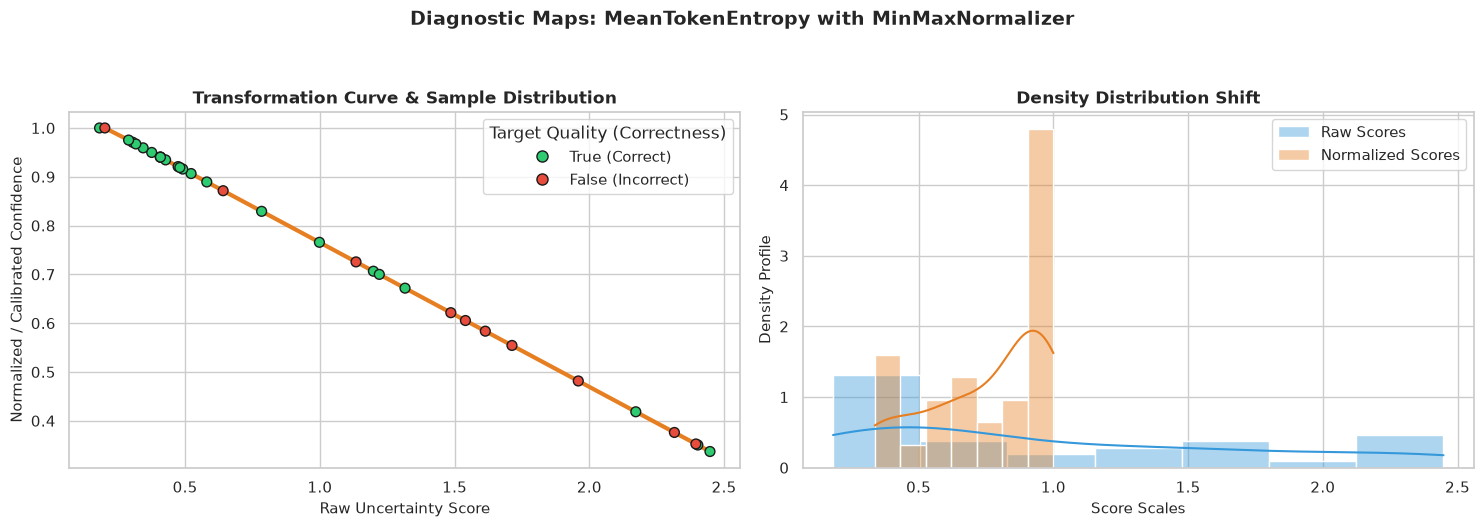

--------------------------------------------------------------------------------


### 📐 Calibration MSE — `MinMaxNormalizer`

--- Calibration Performance: MinMaxNormalizer (LM-Polygraph) ---


,UQ Technique,Calibration MSE,Sample Count
0,MeanTokenEntropy,0.176197,33


---
# 🚀 Normalization Method: `QuantileNormalizer`

### 📊 Mapping Plot — UQ Technique: `MeanTokenEntropy`

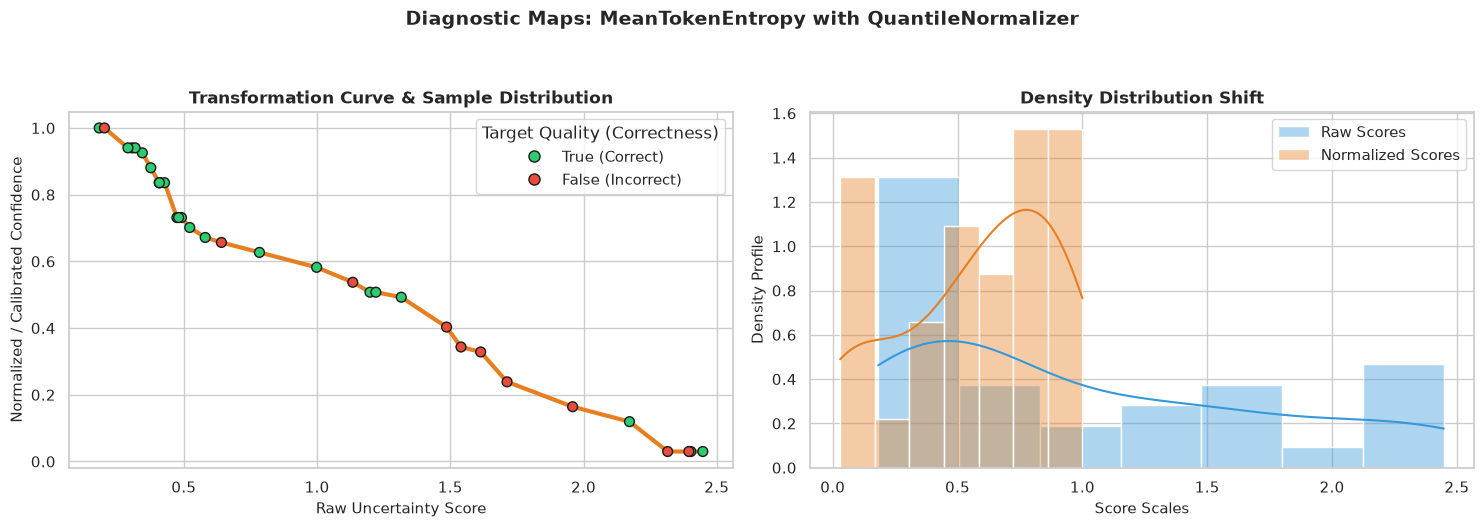

--------------------------------------------------------------------------------


### 📐 Calibration MSE — `QuantileNormalizer`

--- Calibration Performance: QuantileNormalizer (LM-Polygraph) ---


,UQ Technique,Calibration MSE,Sample Count
0,MeanTokenEntropy,0.195758,33


---
# 🚀 Normalization Method: `BinnedPCCNormalizer`

### 📊 Mapping Plot — UQ Technique: `MeanTokenEntropy`

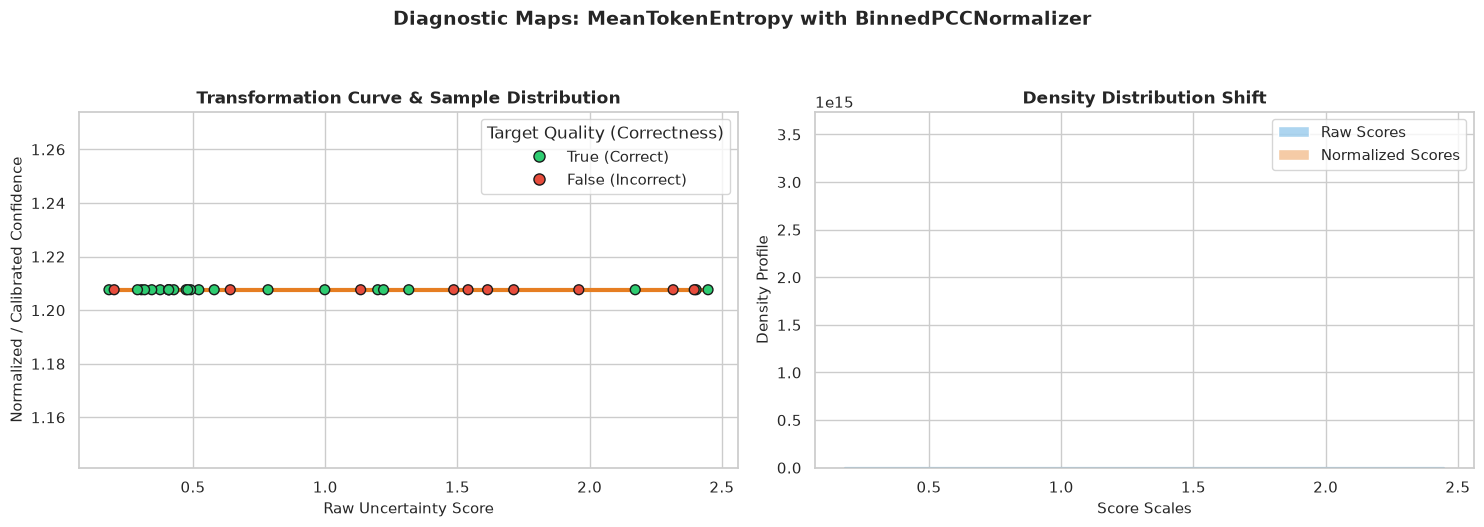

--------------------------------------------------------------------------------


### 📐 Calibration MSE — `BinnedPCCNormalizer`

--- Calibration Performance: BinnedPCCNormalizer (LM-Polygraph) ---


,UQ Technique,Calibration MSE,Sample Count
0,MeanTokenEntropy,0.471971,33


---
# 🚀 Normalization Method: `IsotonicRegression`

### 📊 Mapping Plot — UQ Technique: `MeanTokenEntropy`

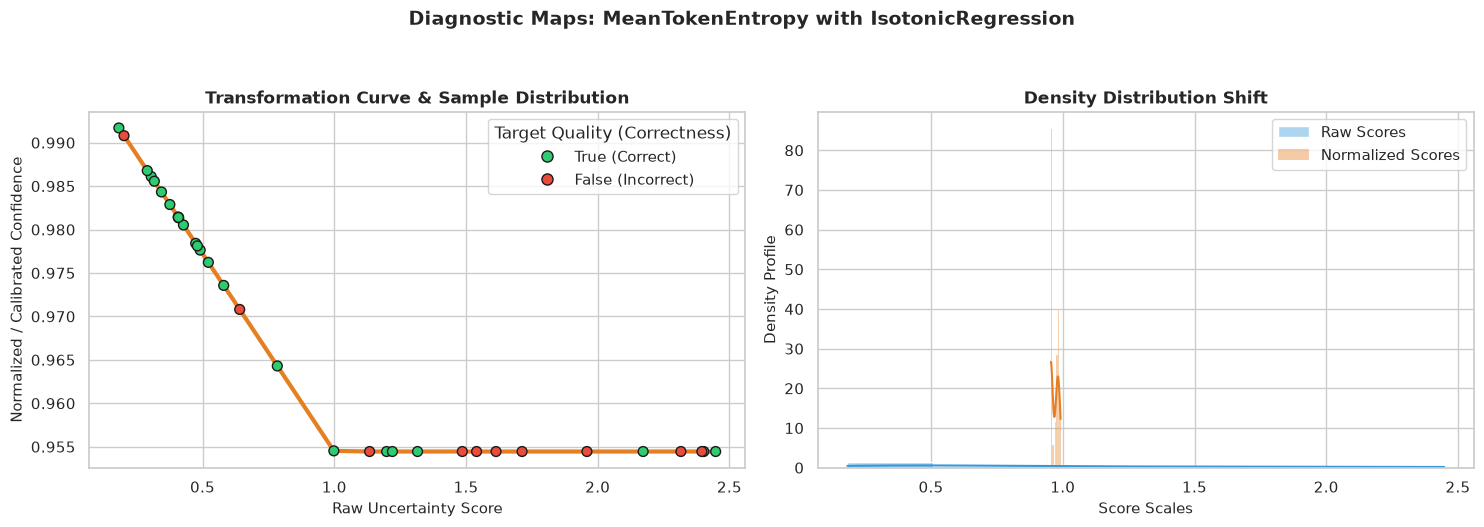

--------------------------------------------------------------------------------


### 📐 Calibration MSE — `IsotonicRegression`

--- Calibration Performance: IsotonicRegression (LM-Polygraph) ---


,UQ Technique,Calibration MSE,Sample Count
0,MeanTokenEntropy,0.279789,33


In [ ]:
from IPython.display import display, Markdown

for method_name in polygraph_methods:
    # Dedicated Markdown header to clearly separate normalization methods
    display(Markdown(f"---\n# 🚀 Normalization Method: `{method_name}`"))

    # 1. Visualization for each technique
    for tech in lm_polygraph_technicques:
        display(Markdown(f"### 📊 Mapping Plot — UQ Technique: `{tech}`"))
        data = polygraph_experiments[method_name][tech]

        visualize_normalization_mapping(
            raw_scores=data["raw_scores"],
            normalized_scores=data["calibrated_scores"],
            qualities=data["qualities"],
            technique_name=tech,
            normalizer_name=method_name
        )

        # Force closure and visual separation of the current plot
        plt.show()
        print("-" * 80)

    # 2. Quantitative Evaluation (MSE)
    display(Markdown(f"### 📐 Calibration MSE — `{method_name}`"))
    polygraph_results_list = []
    for tech in lm_polygraph_technicques:
        data = polygraph_experiments[method_name][tech]
        for i in range(len(data["calibrated_scores"])):
            polygraph_results_list.append({
                "UQ Technique": tech,
                "Calibrated Score": data["calibrated_scores"][i],
                "Target Quality": data["qualities"][i]
            })

    df_polygraph = pd.DataFrame(polygraph_results_list)
    mse_summary = calibration_MSE(df_polygraph)
    print(f"--- Calibration Performance: {method_name} (LM-Polygraph) ---")
    display(mse_summary)

    print("\n" + "="*80 + "\n")

---
# 🚀 Normalization Method: `ISOTONIC`

### 📊 Mapping Plot — UQ Technique: `SequenceProbability`

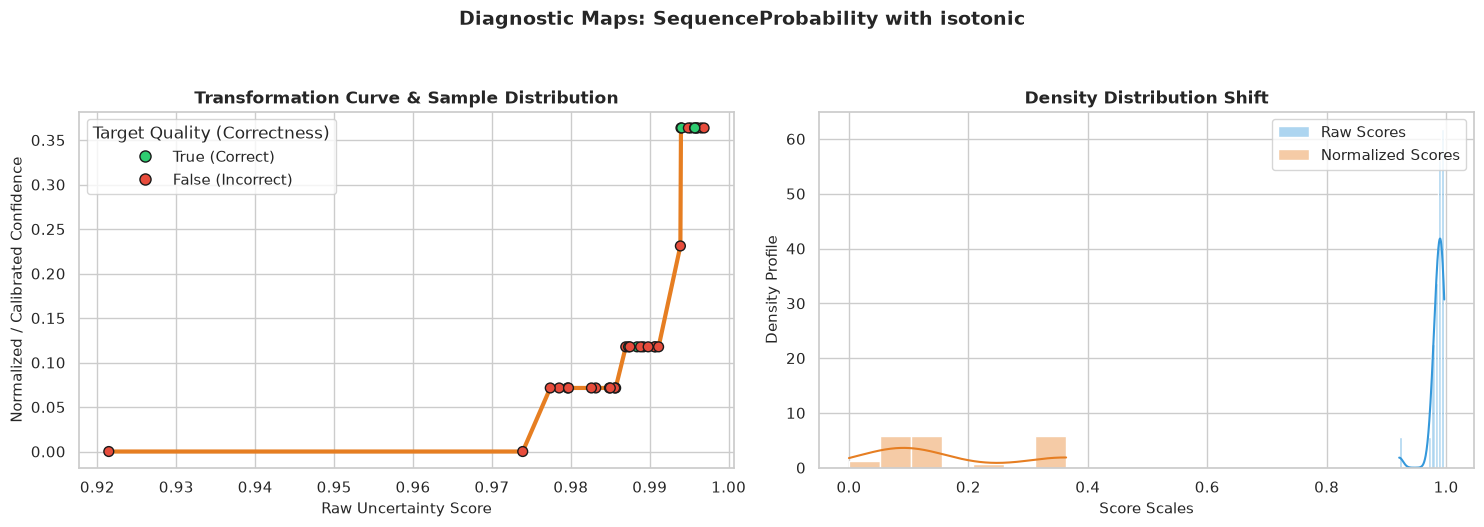

#### 📋 Native Framework Metrics (`SequenceProbability`)

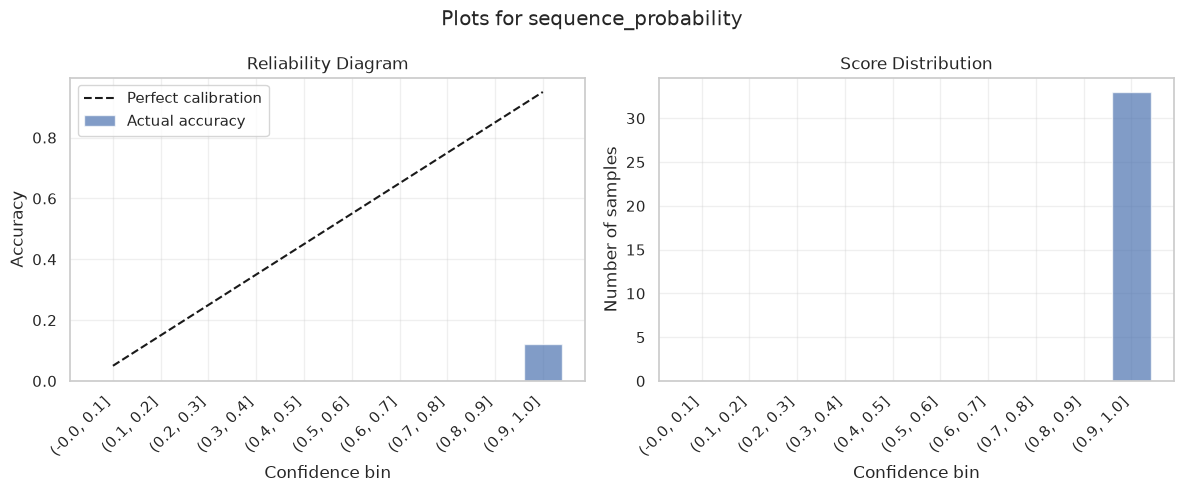

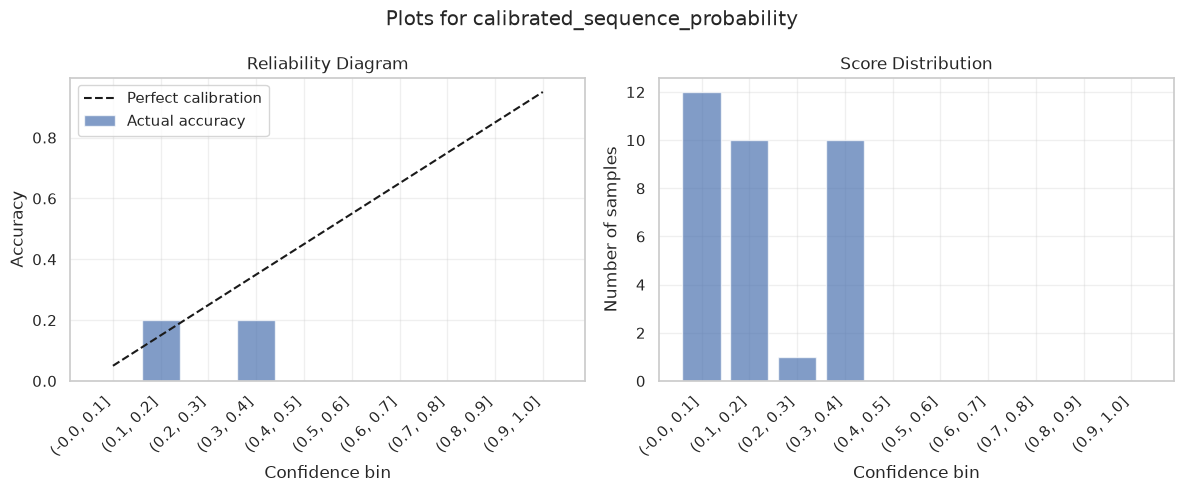

,average_confidence,average_accuracy,calibration_gap,brier_score,log_loss,ece,mce
sequence_probability,0.986563,0.121212,0.865350,0.854357,3.993369,0.865350,0.865350
calibrated_sequence_probability,0.174489,0.121212,0.053277,0.110302,0.361342,0.103188,0.231026


--------------------------------------------------------------------------------


### 📐 Calibration MSE Summary — `isotonic`

,UQ Technique,Calibration MSE,Sample Count
0,SequenceProbability,0.110302,33


---
# 🚀 Normalization Method: `PLATT`

### 📊 Mapping Plot — UQ Technique: `SequenceProbability`

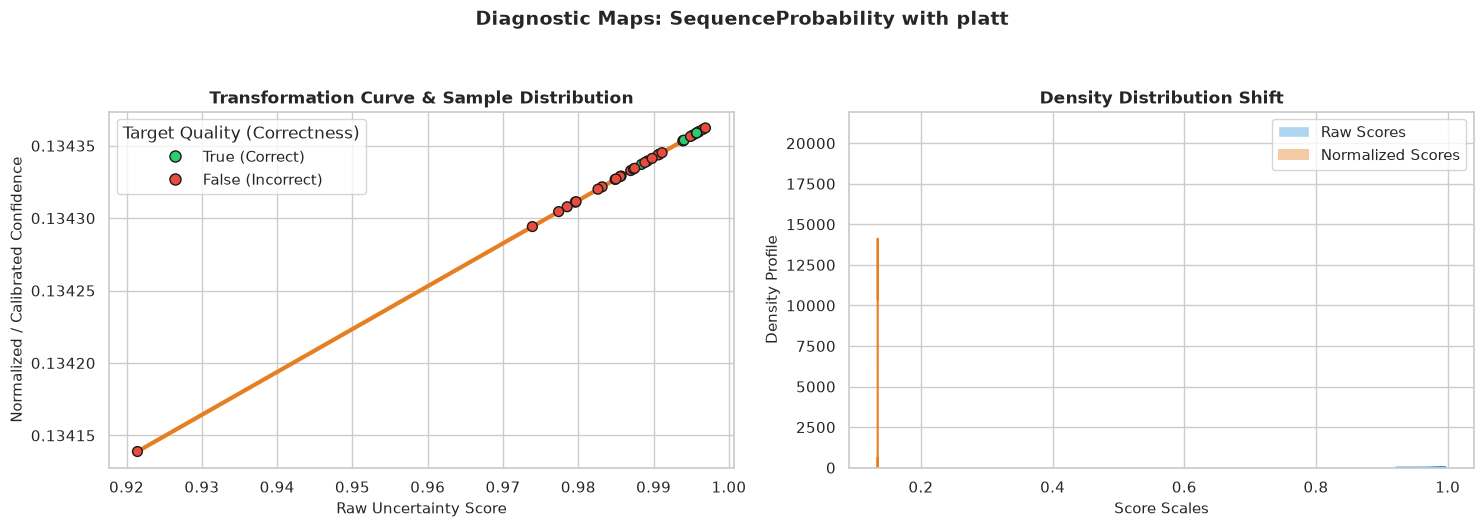

#### 📋 Native Framework Metrics (`SequenceProbability`)

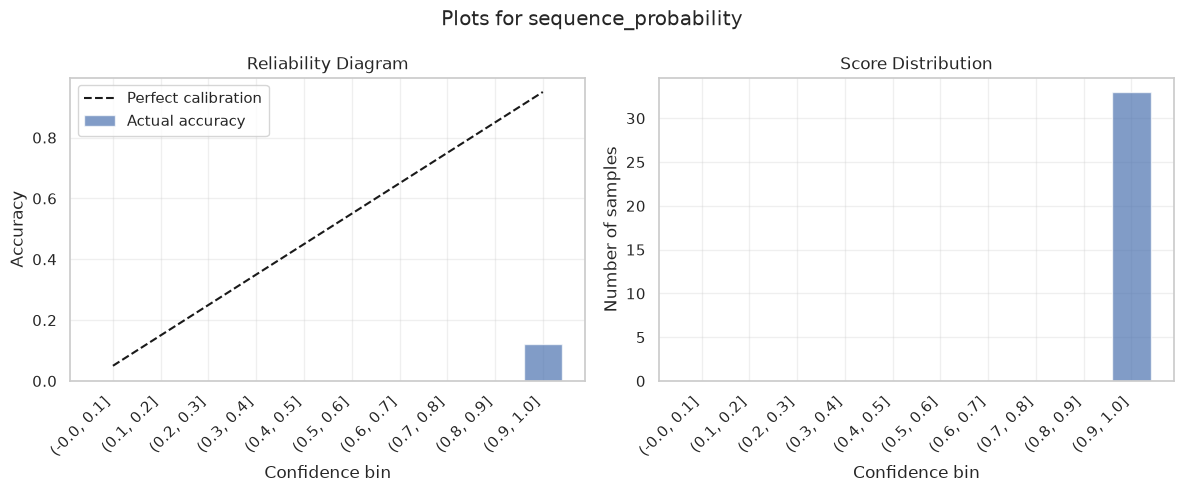

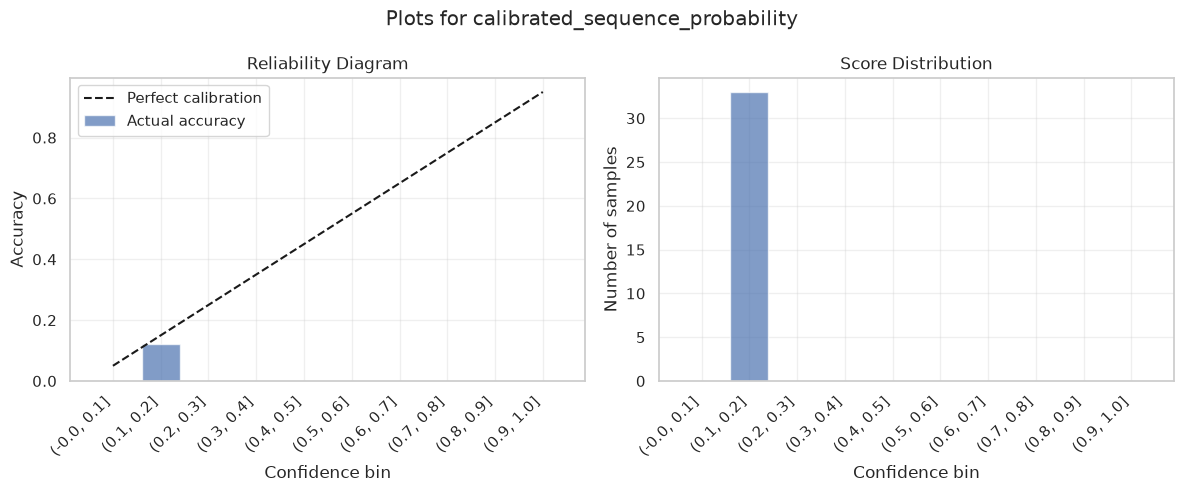

,average_confidence,average_accuracy,calibration_gap,brier_score,log_loss,ece,mce
sequence_probability,0.986563,0.121212,0.86535,0.854357,3.993369,0.86535,0.86535
calibrated_sequence_probability,0.134332,0.121212,0.01312,0.106688,0.370080,0.01312,0.01312


--------------------------------------------------------------------------------


### 📐 Calibration MSE Summary — `platt`

,UQ Technique,Calibration MSE,Sample Count
0,SequenceProbability,0.106688,33


In [ ]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd
from uqlm.calibration import evaluate_calibration

# ==========================================
# PHASE 2: Visualization and Evaluation
# ==========================================

for method_name in uqlm_methods:
    display(Markdown(f"---\n# 🚀 Normalization Method: `{method_name.upper()}`"))

    test_result = uqlm_experiments[method_name]

    # 1. Safe and manual DataFrame reconstruction
    df_data = {"response_correct": test_result[uqlm_techniques[0]]["qualities"]}
    for tech in uqlm_techniques:
        df_data[tech] = test_result[tech]["calibrated_scores"]


    # 2. Visualization of Mappings and Native Metrics per Technique
    for tech in uqlm_techniques:
        display(Markdown(f"### 📊 Mapping Plot — UQ Technique: `{tech}`"))

        visualize_normalization_mapping(
            raw_scores=test_result[tech]["raw_scores"],
            normalized_scores=test_result[tech]["calibrated_scores"],
            qualities=test_result[tech]["qualities"],
            technique_name=tech,
            normalizer_name=method_name
        )
        plt.show()

        # Native framework metrics by passing the respective global test UQResult
        display(Markdown(f"#### 📋 Native Framework Metrics (`{tech}`)"))
        native_metrics = evaluate_calibration(
            test_result[tech]["uqlm_result"],
            test_result[tech]["qualities"]
        )
        display(native_metrics)
        print("-" * 80)

    # 3. Custom MSE Evaluation (Summary)
    display(Markdown(f"### 📐 Calibration MSE Summary — `{method_name}`"))
    uqlm_results_list = []
    for tech in uqlm_techniques:
        data = uqlm_experiments[method_name][tech]
        for i in range(len(data["calibrated_scores"])):
            uqlm_results_list.append({
                "UQ Technique": tech,
                "Calibrated Score": data["calibrated_scores"][i],
                "Target Quality": data["qualities"][i]
            })

    df_uqlm = pd.DataFrame(uqlm_results_list)
    display(calibration_MSE(df_uqlm))

    print("\n" + "="*80 + "\n")

> 💡 **Observation:**

> **1. MeanTokenEntropy (LM-Polygraph Normalization)**
> * **MinMax vs. Quantile:** MinMax Scaling achieved the lowest error (MSE: 0.1762) compared to Quantile Mapping (MSE: 0.1958), indicating stable linear bounds for token entropy.
> * **Binned PCC Limitation:** Binned PCC underperformed significantly (MSE: 0.4720) due to high variance and information loss from bin discretization on a limited sample count.
> * **Isotonic Performance:** Isotonic Regression yielded an intermediate result (MSE: 0.2799), trailing behind simple linear min-max scaling for this specific metric.
>
>
> **2. SequenceProbability (UQLM Calibration)**
> * **Overconfidence Mitigation:** Raw sequence probabilities showed severe overconfidence (98.6% confidence vs. 12.1% accuracy, Brier score 0.854). Both Platt Scaling and Isotonic Regression successfully aligned confidence to realistic levels (13.4% and 17.4%) and reduced the calibration gap.
> * **Platt vs. Isotonic:** Platt Scaling slightly outperformed Isotonic Regression (Brier score 0.1067 vs. 0.1103), acting as an effective parametric regularizer that avoided small-sample overfitting.
>
>

<a name='4.10'></a>


---
### 🏁 **Summary & Concluding Remarks**

Normalization and calibration are fundamental steps that make uncertainty quantification (UQ) scores effective for detecting LLM hallucinations by translating raw metrics into standardized, interpretable intervals between 0 and 1.

#### **✅ Core Takeaways**

> * **📐 Normalization:** Ideal when the primary objective is scale uniformity, score comparability, or preserving relative uncertainty rankings across disparate models.

> * **📈 Calibration:** Essential when confidence scores act as absolute decision thresholds (e.g., routing to human oversight if confidence $< 0.95$). Calibration is the only rigorous method ensuring that numeric metrics directly map to empirical success probabilities.



---

#### **⚖️ Framework Comparison: Quick Decision Matrix**

| Method / Class | Framework Support | Category | Computational Complexity | When to Use (Selection Guide) |
| --- | --- | --- | --- | --- |
| **Linear Scaling** (`MinMaxNormalizer`) | `lm-polygraph` | Pure Normalization | $O(N)$ | High-throughput, low-overhead systems where basic rank-ordering suffices. |
| **Percentile Mapping** (`QuantileNormalizer`) | `lm-polygraph` | Pure Normalization | $O(N \log N)$ | Dealing with heavily skewed distributions where forcing a uniform spread is needed. |
| **Platt Scaling** (`PlattPCCNormalizer`) | `uqlm` | Performance Calibration | $O(N)$ | Smaller datasets where the relationship is roughly sigmoid-shaped. |
| **Binned PCC** (`BinnedPCCNormalizer`) | `lm-polygraph` | Performance Calibration | $O(N \log N)$ | Scenarios with sufficient labeled data requiring an interpretable probability mapping via binning. |
| **Isotonic PCC** (`IsotonicPCCNormalizer`) | **Both** (`lm-polygraph` & `uqlm`) | Performance Calibration | $O(N \log N)$ | Dense calibration data needing flexible, non-parametric handling of complex curves while strictly preserving ranks. |

---

### **References**

* <a name="ref-vashurin-2025"></a>**[Vashurin et al., 2025]** Roman Vashurin, Ekaterina Fadeeva, Artem Vazhentsev, Lyudmila Rvanova, Daniil Vasilev, Akim Tsvigun, Sergey Petrakov, Rui Xing, Abdelrahman Sadallah, Kirill Grishchenkov, Alexander Panchenko, Timothy Baldwin, Preslav Nakov, Maxim Panov, and Artem Shelmanov. *"Benchmarking Uncertainty Quantification Methods for Large Language Models with LM-Polygraph"*. Transactions of the Association for Computational Linguistics, vol. 13, pp. 220–248, 2025. https://aclanthology.org/2025.tacl-1.11/

* <a name="ref-lamb-2026"></a>**[Lamb et al., 2026]** Tom A. Lamb, Desi R. Ivanova, Philip H. S. Torr, and Tim G. J. Rudner. "Improving Semantic Uncertainty Quantification in Language Model Question-Answering via Token-Level Temperature Scaling". Proceedings of the 29th International Conference on Artificial Intelligence and Statistics (AISTATS), PMLR, Volume 300, Tangier, Morocco, 2026. https://arxiv.org/pdf/2604.07172.